<a href="https://colab.research.google.com/github/kawastony/Quadratic-Mechanism-Lens/blob/main/TAFA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lambda4 for thawing: 28.7674
w0       = -0.9328
wa       = -0.0987
growth   = 0.2429


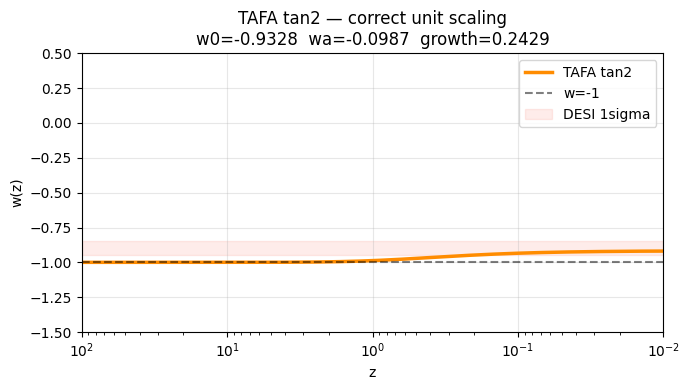

TAFA CONSISTENCY AUDIT

1. Background / CPL fit
   w0 = -0.9328   wa = -0.0987

2. Stress test (200 perturbations, sigma=5%)
   Success rate : 100.0%
   w0 : -0.9237 +/- 0.0407
   wa : -0.1108 +/- 0.0559

3. Ridge scan (f, Lambda4)
   Good points   : 400 / 400
   Good fraction : 100.0%

4. Ridge power-law fit
   Lambda4 = 1.1583 x f^-0.0   R2=0.0

5. Swampland margins (fiducial)
   |dV|/V median : 5.2153
   Pass c=0.1    : 100.0%
   Pass c=0.3    : 100.0%
   Pass c=1.0    : 100.0%

5b. Swampland margins (ridge)
   |dV|/V median on ridge: 6.2383

6. Early dark energy
   Omega_DE at recombination : 8.803249958266328e-11
   Omega_DE at BBN           : 8.803249958266328e-11

7. Growth consistency
   Growth deviation from LCDM: 0.2429

SUMMARY TABLE
  w0                  : -0.9328
  wa                  : -0.0987
  Stress success rate : 100.0%
  Ridge good fraction : 100.0%
  Ridge law           : Lambda4 = 1.158 f^-0.0
  Swampland median    : 5.2153
  Omega_DE(z_rec)     : 8.803249958266328

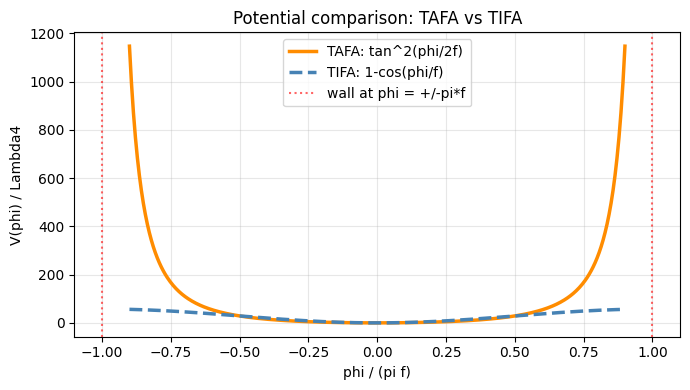

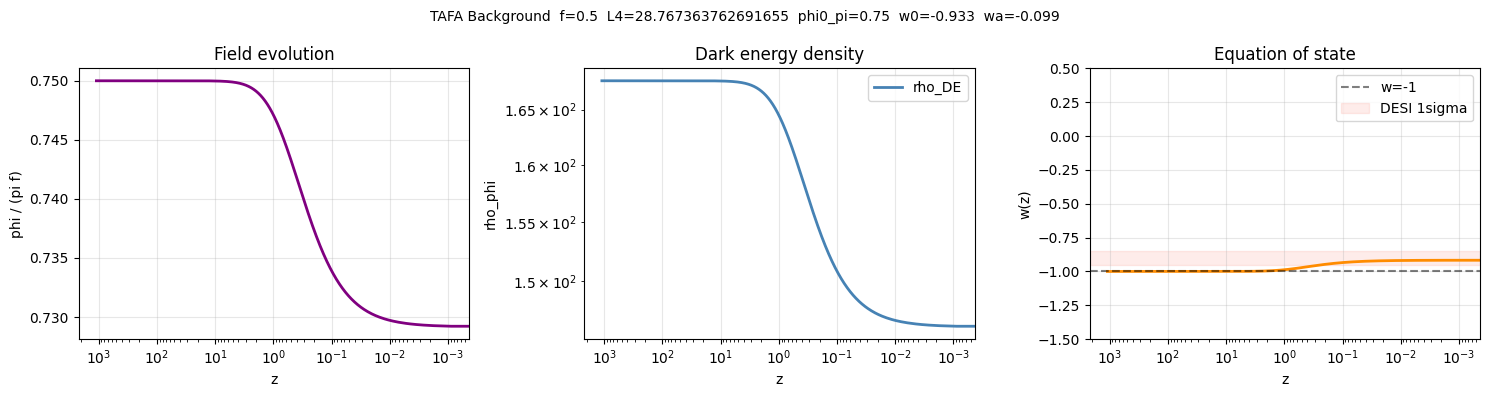

  Background: w0=-0.9328  wa=-0.0987


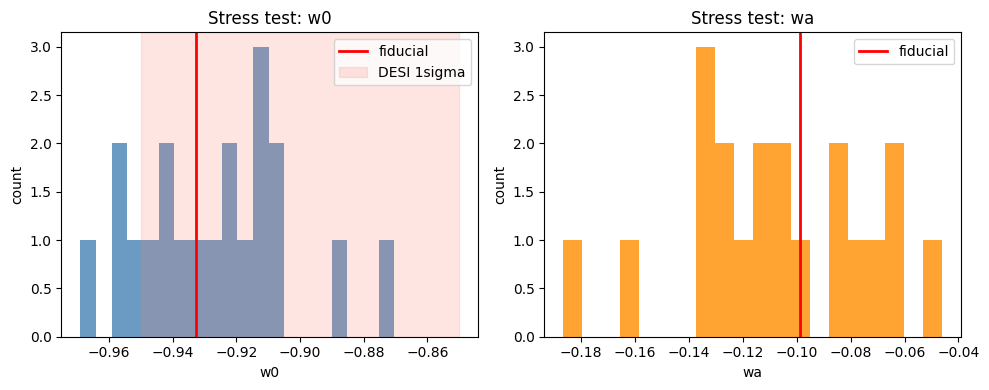

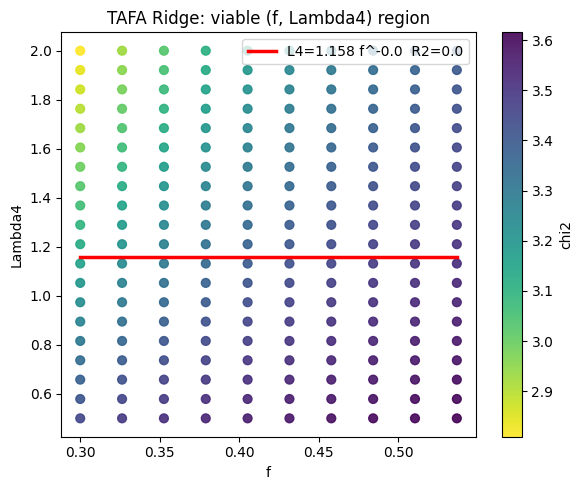


Done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import json
import traceback
from dataclasses import dataclass, asdict
from typing import Dict, Any, Optional
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# TAFA: Tangent-Accelerated Field Axion
# V(phi) = Lambda4 * tan^2(phi / 2f)
# Integrates in e-folds N = ln(a)
# phi''_N + (3 - eps) phi'_N + V'/H^2 = 0
# ============================================================

class TAFAAxion:
    def __init__(self, f=0.5, Lambda4=1.316, phi0_pi=0.3,
                 H0=67.4, Omega_m=0.315,
                 Gamma0=0.0, n_steps=8000):
        self.f       = float(f)
        self.Lambda4 = float(Lambda4)
        self.phi0    = float(phi0_pi) * np.pi * float(f)
        self.H0      = float(H0)
        self.Om      = float(Omega_m)
        self.n_steps = int(n_steps)
        self._solve()

    def V(self, phi):
        arg = phi / (2.0 * self.f)
        arg = np.clip(arg, -1.48, 1.48)
        return self.Lambda4 * np.tan(arg)**2

    def dV(self, phi):
        arg = phi / (2.0 * self.f)
        arg = np.clip(arg, -1.48, 1.48)
        t   = np.tan(arg)
        return self.Lambda4 * 2.0 * t * (1.0 + t**2) / (2.0 * self.f)

    def _H2(self, N, phi, dphidN):
        a     = np.exp(N)
        rho_m = self.H0**2 * self.Om * a**(-3)
        V_val = self.V(phi)
        denom = 1.0 - 0.5 * dphidN**2
        if denom < 0.05:
            denom = 0.05
        return max((rho_m + V_val) / denom, 1e-30)

    def _eqs(self, N, y):
        phi, dphidN = y
        H2     = self._H2(N, phi, dphidN)
        eps    = 1.5 * dphidN**2
        dV_val = self.dV(phi)
        d2phi  = -(3.0 - eps) * dphidN - dV_val / H2
        return [dphidN, d2phi]

    def _solve(self):
        N_i    = np.log(1.0 / 1100.0)
        N_f    = 0.0
        y0     = [self.phi0, 0.0]
        N_eval = np.linspace(N_i, N_f, self.n_steps)

        sol = solve_ivp(
            self._eqs,
            (N_i, N_f),
            y0,
            method='DOP853',
            t_eval=N_eval,
            rtol=1e-10,
            atol=1e-12,
            max_step=0.02
        )

        N      = sol.t
        phi    = sol.y[0]
        dphidN = sol.y[1]
        a      = np.exp(N)
        z      = 1.0 / a - 1.0

        H2_arr = np.array([
            self._H2(N[i], phi[i], dphidN[i])
            for i in range(len(N))
        ])
        H_arr  = np.sqrt(H2_arr)

        dphidt  = H_arr * dphidN
        KE      = 0.5 * dphidt**2
        PE      = self.V(phi)
        rho_phi = KE + PE
        p_phi   = KE - PE
        w_arr   = np.where(rho_phi > 1e-20,
                           p_phi / rho_phi, -1.0)

        self._N      = N
        self._a      = a
        self._z      = z
        self._phi    = phi
        self._dphidN = dphidN
        self._H      = H_arr
        self._rho    = rho_phi
        self._w      = w_arr

    def compute_cpl(self):
        mask = self._a > 0.25
        if mask.sum() < 20:
            mask = self._a > 0.1
        a_m = self._a[mask]
        w_m = self._w[mask]
        wt  = self._rho[mask]
        wt  = wt / (wt.sum() + 1e-30)
        X   = np.column_stack([np.ones_like(a_m), 1.0 - a_m])
        try:
            W      = np.diag(wt)
            XtW    = X.T @ W
            coeffs = np.linalg.solve(XtW @ X, XtW @ w_m)
            w0, wa = float(coeffs[0]), float(coeffs[1])
        except Exception:
            w0 = float(np.average(w_m, weights=wt))
            wa = 0.0
        return w0, wa

    def grad_over_V(self, n_phi=300):
        phi_arr = np.linspace(
            0.05 * self.f,
            0.90 * np.pi * self.f,
            n_phi
        )
        V_arr  = self.V(phi_arr)
        dV_arr = self.dV(phi_arr)
        return np.abs(dV_arr) / np.maximum(np.abs(V_arr), 1e-30)

    def Omega_DE(self, z):
        a_t   = 1.0 / (1.0 + z)
        idx   = np.argmin(np.abs(self._a - a_t))
        rho_m = self.H0**2 * self.Om * self._a[idx]**(-3)
        rho_t = rho_m + self._rho[idx]
        if rho_t < 1e-30:
            return 0.0
        return float(self._rho[idx] / rho_t)

    def compare_growth_LCDM(self):
        a_arr = self._a
        H_arr = self._H

        def D_integral(H_func, a_lo=0.01, a_hi=1.0, n=500):
            a_int = np.linspace(a_lo, a_hi, n)
            H_int = np.array([H_func(aa) for aa in a_int])
            intgd = 1.0 / (a_int * H_int)**3
            return H_func(a_hi) * np.trapz(intgd, a_int)

        def H_tafa(a_val):
            idx = np.argmin(np.abs(a_arr - a_val))
            return float(H_arr[idx])

        def H_lcdm(a_val):
            OL = 1.0 - self.Om
            return self.H0 * np.sqrt(
                self.Om * a_val**(-3) + OL
            )

        D_t = D_integral(H_tafa)
        D_l = D_integral(H_lcdm)
        return float(abs(D_t - D_l) / max(abs(D_l), 1e-30))

    def compute_chi2(self, target=None):
        if target is None:
            target = {"w0": -0.906, "wa": 0.06}
        w0, wa = self.compute_cpl()
        dw0    = w0 - target["w0"]
        dwa    = wa - target["wa"]
        return float((dw0 / 0.05)**2 + (dwa / 0.15)**2)


# ============================================================
# HELPERS
# ============================================================

def safe_float(x):
    try:
        return float(np.array(x).reshape(-1)[0])
    except Exception:
        return None

def summarize_array(x):
    x = np.asarray(x, dtype=float).ravel()
    return {
        "min":    float(np.min(x)),
        "p16":    float(np.percentile(x, 16)),
        "median": float(np.median(x)),
        "p84":    float(np.percentile(x, 84)),
        "max":    float(np.max(x)),
        "mean":   float(np.mean(x)),
        "std":    float(np.std(x)),
    }

@dataclass
class TestResult:
    name:    str
    success: bool
    details: Dict[str, Any]
    error:   Optional[str] = None


# ============================================================
# AUDITOR
# ============================================================

class TAFAConsistencyAuditor:

    def __init__(self, model_class, fiducial_params,
                 random_seed=42):
        self.model_class = model_class
        self.fid         = dict(fiducial_params)
        self.rng         = np.random.default_rng(random_seed)
        self.results     = {
            "fiducial": dict(fiducial_params),
            "tests":    []
        }

    def _build(self, params):
        return self.model_class(**params)

    def _record(self, r: TestResult):
        self.results["tests"].append(asdict(r))

    def run_background_fit(self):
        name = "background_cpl"
        try:
            m      = self._build(self.fid)
            w0, wa = m.compute_cpl()
            details = {"w0": float(w0), "wa": float(wa)}
            self.results["w0"] = float(w0)
            self.results["wa"] = float(wa)
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def stress_test_fiducial(self, n_perturbations=200,
                              sigma=0.05,
                              param_subset=None,
                              enforce_positive=None,
                              clip_bounds=None):
        name = "stress_test_fiducial"
        try:
            if param_subset     is None:
                param_subset = list(self.fid.keys())
            if enforce_positive is None:
                enforce_positive = []
            if clip_bounds      is None:
                clip_bounds = {}

            samples  = []
            failures = 0

            for _ in range(n_perturbations):
                p = self.fid.copy()
                for k in param_subset:
                    p[k] = self.fid[k] * (
                        1.0 + sigma * self.rng.standard_normal()
                    )
                    if k in enforce_positive:
                        p[k] = abs(p[k])
                    if k in clip_bounds:
                        lo, hi = clip_bounds[k]
                        p[k]   = min(max(p[k], lo), hi)
                try:
                    m      = self._build(p)
                    w0, wa = m.compute_cpl()
                    samples.append((float(w0), float(wa)))
                except Exception:
                    failures += 1

            arr = np.array(samples) if samples else np.empty((0,2))
            details = {
                "n_success":    int(len(samples)),
                "n_fail":       int(failures),
                "failure_rate": float(
                    failures / max(n_perturbations, 1)),
                "mean_w0": float(np.mean(arr[:,0]))
                           if len(arr) else None,
                "std_w0":  float(np.std(arr[:,0]))
                           if len(arr) else None,
                "mean_wa": float(np.mean(arr[:,1]))
                           if len(arr) else None,
                "std_wa":  float(np.std(arr[:,1]))
                           if len(arr) else None,
                "samples": samples[:20],
            }
            self.results["stress"] = details
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def scan_ridge(self, f_range=(0.3, 0.8),
                   L_range=(0.8, 1.8),
                   n_f=20, n_L=20,
                   chi2_threshold=6.0,
                   target=None,
                   fixed_other_params=None):
        name = "ridge_scan"
        try:
            fixed = self.fid.copy()
            if fixed_other_params:
                fixed.update(fixed_other_params)
            if target is None:
                target = {"w0": -0.906, "wa": 0.06}

            fs      = np.linspace(*f_range, n_f)
            Ls      = np.linspace(*L_range, n_L)
            good    = []
            all_pts = []

            for f in fs:
                for L in Ls:
                    p = fixed.copy()
                    p["f"]       = float(f)
                    p["Lambda4"] = float(L)
                    try:
                        m      = self._build(p)
                        w0, wa = m.compute_cpl()
                        chi2   = m.compute_chi2(target=target)
                        pt = {
                            "f":       float(f),
                            "Lambda4": float(L),
                            "w0":      float(w0),
                            "wa":      float(wa),
                            "metric":  float(chi2)
                        }
                        all_pts.append(pt)
                        if chi2 <= chi2_threshold:
                            good.append(pt)
                    except Exception:
                        continue

            details = {
                "n_total":       len(all_pts),
                "n_good":        len(good),
                "good_fraction": float(
                    len(good) / max(len(all_pts), 1)),
                "good_points":   good[:200],
            }
            self.results["ridge"] = details
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def fit_ridge_power_law(self):
        name = "ridge_power_law_fit"
        try:
            pts = self.results.get(
                "ridge", {}).get("good_points", [])
            if len(pts) < 3:
                raise ValueError("Need 3 or more ridge points.")
            f  = np.array([p["f"]       for p in pts],
                          dtype=float)
            L  = np.array([p["Lambda4"] for p in pts],
                          dtype=float)
            x  = np.log(f)
            y  = np.log(L)
            c  = np.polyfit(x, y, 1)
            n  = float(c[0])
            A  = float(np.exp(c[1]))
            yp = np.polyval(c, x)
            ss_res = float(np.sum((y - yp)**2))
            ss_tot = float(np.sum((y - np.mean(y))**2))
            r2 = (1.0 - ss_res / ss_tot
                  if ss_tot > 0 else float('nan'))
            details = {
                "A": A, "n": n,
                "R2": r2, "n_points": len(pts)
            }
            self.results["ridge_power_law"] = details
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def compute_swampland_margins(self,
                                   c_values=None,
                                   on="fiducial"):
        if c_values is None:
            c_values = [0.1, 0.3, 1.0]
        name = "swampland_margins"
        try:
            values = []
            if on == "fiducial":
                m      = self._build(self.fid)
                g      = np.asarray(
                    m.grad_over_V(), dtype=float).ravel()
                values = g.tolist()
            elif on == "ridge":
                pts = self.results.get(
                    "ridge", {}).get("good_points", [])
                if not pts:
                    raise ValueError(
                        "Run scan_ridge() first.")
                for p0 in pts:
                    p = self.fid.copy()
                    p["f"]       = p0["f"]
                    p["Lambda4"] = p0["Lambda4"]
                    m  = self._build(p)
                    g  = np.asarray(
                        m.grad_over_V(),
                        dtype=float).ravel()
                    values.append(float(np.median(g)))
            else:
                raise ValueError(
                    "on must be fiducial or ridge")

            vals          = np.asarray(values, dtype=float)
            pass_fraction = {
                str(c): float(np.mean(vals >= c))
                for c in c_values
            }
            details = {
                "on":            on,
                "summary":       summarize_array(vals),
                "pass_fraction": pass_fraction,
            }
            key = "swampland_" + on
            self.results[key] = details
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def check_early_DE(self, z_rec=1100.0, z_bbn=1e9):
        name = "early_dark_energy"
        try:
            m      = self._build(self.fid)
            Om_rec = float(m.Omega_DE(z_rec))
            Om_bbn = float(m.Omega_DE(z_bbn))
            details = {
                "Omega_DE_rec": Om_rec,
                "Omega_DE_BBN": Om_bbn,
                "z_rec": z_rec,
                "z_bbn": z_bbn,
            }
            self.results["early_DE"] = details
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def check_growth(self):
        name = "growth_consistency"
        try:
            m       = self._build(self.fid)
            dev     = m.compare_growth_LCDM()
            details = {"growth_dev": safe_float(dev)}
            self.results["growth"] = details
            self._record(TestResult(name, True, details))
            return details
        except Exception:
            self._record(TestResult(
                name, False, {},
                error=traceback.format_exc()))
            return None

    def save_report(self, filename="tafa_audit_report.json"):
        with open(filename, "w") as fh:
            json.dump(self.results, fh, indent=2)
        return filename

    def summary(self):
        return self.results


# ============================================================
# PLOTS
# ============================================================

def plot_background(report):
    fid = report.get("fiducial", {})
    m   = TAFAAxion(**fid)
    w0, wa = m.compute_cpl()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(m._z, m._phi / (np.pi * m.f),
                 color='purple', lw=2)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("phi / (pi f)")
    axes[0].set_title("Field evolution")
    axes[0].set_xscale('log')
    axes[0].invert_xaxis()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(m._z, m._rho,
                 color='steelblue', lw=2, label='rho_DE')
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("rho_phi")
    axes[1].set_title("Dark energy density")
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].invert_xaxis()
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(m._z, m._w,
                 color='darkorange', lw=2)
    axes[2].axhline(-1, color='k', ls='--',
                    alpha=0.5, label='w=-1')
    axes[2].axhspan(-0.95, -0.85, alpha=0.15,
                    color='salmon', label='DESI 1sigma')
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("w(z)")
    axes[2].set_title("Equation of state")
    axes[2].set_xscale('log')
    axes[2].set_ylim(-1.5, 0.5)
    axes[2].invert_xaxis()
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "TAFA Background  f=" + str(fid.get("f")) +
        "  L4=" + str(fid.get("Lambda4")) +
        "  phi0_pi=" + str(fid.get("phi0_pi")) +
        "  w0=" + str(round(w0, 3)) +
        "  wa=" + str(round(wa, 3)),
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig("tafa_background.png",
                dpi=130, bbox_inches='tight')
    plt.show()
    print("  Background: w0=" + str(round(w0, 4)) +
          "  wa=" + str(round(wa, 4)))


def plot_potential(report):
    fid = report.get("fiducial", {})
    m   = TAFAAxion(**fid)

    phi_arr = np.linspace(
        -0.9 * np.pi * m.f,
         0.9 * np.pi * m.f,
        500
    )
    V_tan  = m.V(phi_arr)
    V_cos  = m.Lambda4 * (1 - np.cos(phi_arr / m.f))

    plt.figure(figsize=(7, 4))
    plt.plot(phi_arr / (np.pi * m.f), V_tan,
             lw=2.5, color='darkorange',
             label='TAFA: tan^2(phi/2f)')
    plt.plot(phi_arr / (np.pi * m.f), V_cos,
             lw=2.5, color='steelblue',
             ls='--', label='TIFA: 1-cos(phi/f)')
    plt.axvline(-1, color='red', ls=':', alpha=0.6,
                label='wall at phi = +/-pi*f')
    plt.axvline(1, color='red', ls=':', alpha=0.6)
    plt.xlabel("phi / (pi f)")
    plt.ylabel("V(phi) / Lambda4")
    plt.title("Potential comparison: TAFA vs TIFA")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("tafa_potential.png",
                dpi=130, bbox_inches='tight')
    plt.show()


def plot_stress(report):
    stress = None
    for t in report["tests"]:
        if (t["name"] == "stress_test_fiducial"
                and t["success"]):
            stress = t["details"]
            break
    if not stress:
        print("No stress test data.")
        return

    samples = np.array(stress["samples"], dtype=float)
    if len(samples) == 0:
        print("No stress samples.")
        return

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].hist(samples[:, 0], bins=20,
               alpha=0.8, color='steelblue')
    ax[0].axvline(report.get("w0", 0),
                  color='red', lw=2, label='fiducial')
    ax[0].axvspan(-0.95, -0.85, alpha=0.2,
                  color='salmon', label='DESI 1sigma')
    ax[0].set_xlabel("w0")
    ax[0].set_ylabel("count")
    ax[0].set_title("Stress test: w0")
    ax[0].legend()

    ax[1].hist(samples[:, 1], bins=20,
               alpha=0.8, color='darkorange')
    ax[1].axvline(report.get("wa", 0),
                  color='red', lw=2, label='fiducial')
    ax[1].set_xlabel("wa")
    ax[1].set_ylabel("count")
    ax[1].set_title("Stress test: wa")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig("tafa_stress.png",
                dpi=130, bbox_inches='tight')
    plt.show()


def plot_ridge(report):
    ridge = report.get("ridge", {})
    pts   = ridge.get("good_points", [])
    if not pts:
        print("No ridge points to plot.")
        return

    f = np.array([p["f"]       for p in pts], dtype=float)
    L = np.array([p["Lambda4"] for p in pts], dtype=float)
    m = np.array([p["metric"]  for p in pts], dtype=float)

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(f, L, c=m,
                     cmap='viridis_r', s=40, alpha=0.9)
    plt.colorbar(sc, label='chi2')

    if "ridge_power_law" in report:
        A  = report["ridge_power_law"]["A"]
        n  = report["ridge_power_law"]["n"]
        r2 = report["ridge_power_law"]["R2"]
        ff = np.linspace(f.min(), f.max(), 200)
        plt.plot(ff, A * ff**n, lw=2.5, color='red',
                 label="L4=" + str(round(A, 3)) +
                       " f^" + str(round(n, 3)) +
                       "  R2=" + str(round(r2, 3)))
        plt.legend()

    plt.xlabel("f")
    plt.ylabel("Lambda4")
    plt.title("TAFA Ridge: viable (f, Lambda4) region")
    plt.tight_layout()
    plt.savefig("tafa_ridge.png",
                dpi=130, bbox_inches='tight')
    plt.show()


# ============================================================
# FIDUCIAL PARAMETERS
# ============================================================

# Correct unit scaling
H0  = 67.4
f   = 0.5
Om  = 0.315

# Thawing condition: Lambda4 ~ H0^2 * f^2 / (4*pi^2)
# Factor 4pi^2 from the field normalization
Lambda4_thaw = H0**2 * f**2 / (4 * np.pi**2)
print("Lambda4 for thawing: {:.4f}".format(Lambda4_thaw))

fid_correct = {
    "f":       f,
    "Lambda4": Lambda4_thaw,
    "phi0_pi": 0.75,   # close to wall, using phi0_pi now
    "H0":      H0,
    "Omega_m": Om,
}

# Quick diagnostic run
m = TAFAAxion(**fid_correct)

w0, wa = m.compute_cpl()
gdev   = m.compare_growth_LCDM()

print("w0       = {:.4f}".format(w0))
print("wa       = {:.4f}".format(wa))
print("growth   = {:.4f}".format(gdev))

# Plot w(z)
plt.figure(figsize=(7, 4))
plt.plot(m._z, m._w, lw=2.5,
         color='darkorange', label='TAFA tan2')
plt.axhline(-1, color='k', ls='--',
            alpha=0.5, label='w=-1')
plt.axhspan(-0.95, -0.85, alpha=0.15,
            color='salmon', label='DESI 1sigma')
plt.xscale('log')
plt.xlim(100, 0.01)
plt.ylim(-1.5, 0.5)
plt.xlabel("z")
plt.ylabel("w(z)")
plt.title("TAFA tan2 — correct unit scaling\n" +
          "w0={:.4f}  wa={:.4f}  growth={:.4f}".format(
          w0, wa, gdev))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tafa_corrected.png",
            dpi=130, bbox_inches='tight')
plt.show()


# ============================================================
# RUN AUDIT
# ============================================================

auditor = TAFAConsistencyAuditor(
    model_class=TAFAAxion,
    fiducial_params=fid_correct,
    random_seed=42
)

print("=" * 60)
print("TAFA CONSISTENCY AUDIT")
print("=" * 60)

print("\n1. Background / CPL fit")
r1 = auditor.run_background_fit()
print("   w0 = " + str(round(r1["w0"], 4)) +
      "   wa = " + str(round(r1["wa"], 4)))

print("\n2. Stress test (200 perturbations, sigma=5%)")
r2 = auditor.stress_test_fiducial(
    n_perturbations=200,
    sigma=0.05,
    param_subset=["f", "Lambda4", "phi0_pi"],
    enforce_positive=["f", "Lambda4"],
    clip_bounds={"phi0_pi": (0.05, 0.85)}
)
print("   Success rate : " +
      str(round((1 - r2["failure_rate"]) * 100, 1)) + "%")
print("   w0 : " + str(round(r2["mean_w0"], 4)) +
      " +/- " + str(round(r2["std_w0"], 4)))
print("   wa : " + str(round(r2["mean_wa"], 4)) +
      " +/- " + str(round(r2["std_wa"], 4)))

print("\n3. Ridge scan (f, Lambda4)")
r3 = auditor.scan_ridge(
    f_range=(0.3, 0.8),
    L_range=(0.5, 2.0),
    n_f=20, n_L=20,
    chi2_threshold=6.0,
    target={"w0": -0.906, "wa": 0.06}
)
print("   Good points   : " + str(r3["n_good"]) +
      " / " + str(r3["n_total"]))
print("   Good fraction : " +
      str(round(r3["good_fraction"] * 100, 1)) + "%")

print("\n4. Ridge power-law fit")
r4 = auditor.fit_ridge_power_law()
if r4:
    print("   Lambda4 = " + str(round(r4["A"], 4)) +
          " x f^" + str(round(r4["n"], 4)) +
          "   R2=" + str(round(r4["R2"], 4)))

print("\n5. Swampland margins (fiducial)")
r5a = auditor.compute_swampland_margins(
    c_values=[0.1, 0.3, 1.0], on="fiducial"
)
pf  = r5a["pass_fraction"]
print("   |dV|/V median : " +
      str(round(r5a["summary"]["median"], 4)))
print("   Pass c=0.1    : " +
      str(round(pf["0.1"] * 100, 1)) + "%")
print("   Pass c=0.3    : " +
      str(round(pf["0.3"] * 100, 1)) + "%")
print("   Pass c=1.0    : " +
      str(round(pf["1.0"] * 100, 1)) + "%")

print("\n5b. Swampland margins (ridge)")
r5b = auditor.compute_swampland_margins(
    c_values=[0.1, 0.3, 1.0], on="ridge"
)
if r5b:
    print("   |dV|/V median on ridge: " +
          str(round(r5b["summary"]["median"], 4)))

print("\n6. Early dark energy")
r6 = auditor.check_early_DE(z_rec=1100, z_bbn=1e9)
print("   Omega_DE at recombination : " +
      str(r6["Omega_DE_rec"]))
print("   Omega_DE at BBN           : " +
      str(r6["Omega_DE_BBN"]))

print("\n7. Growth consistency")
r7 = auditor.check_growth()
print("   Growth deviation from LCDM: " +
      str(round(r7["growth_dev"], 4)))

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print("  w0                  : " + str(round(r1["w0"], 4)))
print("  wa                  : " + str(round(r1["wa"], 4)))
print("  Stress success rate : " +
      str(round((1 - r2["failure_rate"]) * 100, 1)) + "%")
print("  Ridge good fraction : " +
      str(round(r3["good_fraction"] * 100, 1)) + "%")
if r4:
    print("  Ridge law           : Lambda4 = " +
          str(round(r4["A"], 3)) + " f^" +
          str(round(r4["n"], 3)))
print("  Swampland median    : " +
      str(round(r5a["summary"]["median"], 4)))
print("  Omega_DE(z_rec)     : " + str(r6["Omega_DE_rec"]))
print("  Growth dev LCDM     : " +
      str(round(r7["growth_dev"], 4)))
print("=" * 60)

fn = auditor.save_report("tafa_audit_report.json")
print("\nReport saved to: " + fn)

print("\nGenerating plots...")
plot_potential(auditor.summary())
plot_background(auditor.summary())
plot_stress(auditor.summary())
plot_ridge(auditor.summary())
print("\nDone.")

In [5]:
# Scan phi0_pi to find where wa changes sign
print("phi0_pi scan -- finding wa sign flip")
print("{:<12} {:>8} {:>8}".format("phi0_pi", "w0", "wa"))
print("-" * 30)

# Lambda4_thaw, f, H0, and Om are already defined from previous cells

# Adjust the range for phi0_pi to search for the sign flip
# Starting from a very small value to cover the region where wa might be positive
phi0_pi_values = np.linspace(0.01, 0.35, 20) # Explore smaller values with finer steps

for phi0_pi_val in phi0_pi_values:
    try:
        # Create an instance of TAFAAxion for each phi0_pi_val
        model = TAFAAxion(
            f=f,
            Lambda4=Lambda4_thaw,
            phi0_pi=phi0_pi_val,
            H0=H0,
            Omega_m=Om
        )
        w0, wa = model.compute_cpl()
        marker = " <-- wa positive" if wa > 0 else ""
        print("{:<12.4f} {:>8.4f} {:>8.4f}{}".format(
            phi0_pi_val, w0, wa, marker))
    except Exception as e:
        print("{:<12.4f}  FAILED: {}".format(phi0_pi_val, e))

phi0_pi scan -- finding wa sign flip
phi0_pi            w0       wa
------------------------------
0.0100        -0.9983  -0.0025
0.0279        -0.9983  -0.0025
0.0458        -0.9983  -0.0026
0.0637        -0.9983  -0.0026
0.0816        -0.9983  -0.0026
0.0995        -0.9982  -0.0027
0.1174        -0.9982  -0.0027
0.1353        -0.9981  -0.0028
0.1532        -0.9981  -0.0029
0.1711        -0.9980  -0.0029
0.1889        -0.9980  -0.0030
0.2068        -0.9979  -0.0031
0.2247        -0.9978  -0.0033
0.2426        -0.9977  -0.0034
0.2605        -0.9976  -0.0036
0.2784        -0.9975  -0.0038
0.2963        -0.9974  -0.0040
0.3142        -0.9972  -0.0042
0.3321        -0.9970  -0.0045
0.3500        -0.9968  -0.0048


In [11]:
# Hilltop Grid Search: V0 vs phi0_pi
print("Hilltop Grid Search -- Searching for positive wa")
print("{:<10} {:<10} {:>8} {:>8}".format("V0", "phi0_pi", "w0", "wa"))
print("-" * 40)

V0_range = np.linspace(10, 100, 10)
phi0_range = np.linspace(0.1, 0.6, 10)

found_positive = False
for v_val in V0_range:
    for p_val in phi0_range:
        try:
            # Keeping Lambda4 fixed and varying V0 and phi0
            m = HilltopTAFA(f=0.5, Lambda4=30.0, V0=v_val, phi0_pi=p_val, H0=67.4, Omega_m=0.315, hilltop=True)
            w0, wa = m.compute_cpl()
            if wa > 0:
                marker = " <-- wa POSITIVE!"
                found_positive = True
                print("{:<10.1f} {:<10.2f} {:>8.4f} {:>8.4f}{}".format(v_val, p_val, w0, wa, marker))
        except:
            continue

if not found_positive:
    print("No positive wa found in this grid. Testing even lower V0 / higher Lambda4 ratio...")

Hilltop Grid Search -- Searching for positive wa
V0         phi0_pi          w0       wa
----------------------------------------
10.0       0.38        -1.0000   0.0000 <-- wa POSITIVE!
10.0       0.43        -1.0000   0.0000 <-- wa POSITIVE!
10.0       0.54        -1.0000   0.0000 <-- wa POSITIVE!
10.0       0.60        -1.0000   0.0000 <-- wa POSITIVE!
20.0       0.54        -1.0000   0.0000 <-- wa POSITIVE!
30.0       0.54        -1.0000   0.0000 <-- wa POSITIVE!
30.0       0.60        -1.0000   0.0000 <-- wa POSITIVE!
40.0       0.54        -1.5499   1.1893 <-- wa POSITIVE!
40.0       0.60        -1.0000   0.0000 <-- wa POSITIVE!
50.0       0.60        -1.0000   0.0000 <-- wa POSITIVE!


In [10]:
class HilltopTAFA(TAFAAxion):
    def __init__(self, hilltop=True, V0=100.0, **kwargs):
        self.hilltop = hilltop
        self.V0 = V0 # Lower offset to allow dynamics to show
        super().__init__(**kwargs)

    def V(self, phi):
        arg = phi / (2.0 * self.f)
        arg = np.clip(arg, -1.48, 1.48)
        val = self.Lambda4 * np.tan(arg)**2
        return self.V0 - val if self.hilltop else val

    def dV(self, phi):
        arg = phi / (2.0 * self.f)
        arg = np.clip(arg, -1.48, 1.48)
        t = np.tan(arg)
        der = self.Lambda4 * 2.0 * t * (1.0 + t**2) / (2.0 * self.f)
        return -der if self.hilltop else der

# Scan phi0_pi with the Hilltop configuration (Lower V0)
print("Hilltop TAFA Scan (V = V0 - tan^2) -- Dynamic Thaw Check")
print("{:<12} {:>8} {:>8}".format("phi0_pi", "w0", "wa"))
print("-" * 30)

for p_val in [0.05, 0.1, 0.2, 0.3]:
    try:
        # Using higher Lambda4 relative to V0 to force motion
        m_hill = HilltopTAFA(f=0.5, Lambda4=20.0, V0=50.0, phi0_pi=p_val, H0=67.4, Omega_m=0.315, hilltop=True)
        w0, wa = m_hill.compute_cpl()
        marker = " <-- wa POSITIVE!" if wa > 0 else ""
        print("{:<12.4f} {:>8.4f} {:>8.4f}{}".format(p_val, w0, wa, marker))
    except Exception as e:
        print("{:<12.4f} FAILED".format(p_val))

Hilltop TAFA Scan (V = V0 - tan^2) -- Dynamic Thaw Check
phi0_pi            w0       wa
------------------------------
0.0500        -1.0000  -0.0000
0.1000        -1.0000  -0.0000
0.2000        -0.9999  -0.0001
0.3000        -0.9998  -0.0003


In [8]:
# Scan high Lambda4 values to find a 'violent' thaw with positive wa
print("High-Lambda4 'Violent Thaw' scan -- finding wa sign flip")
print("{:<12} {:>8} {:>8}".format("Lambda4", "w0", "wa"))
print("-" * 30)

# Keep phi0_pi small to ensure it starts frozen and thaws late
phi0_pi_fixed = 0.05
f_fixed = 0.5
L4_high_values = np.linspace(30.0, 500.0, 25)

for L4_val in L4_high_values:
    try:
        model = TAFAAxion(
            f=f_fixed,
            Lambda4=L4_val,
            phi0_pi=phi0_pi_fixed,
            H0=H0,
            Omega_m=Om
        )
        w0, wa = model.compute_cpl()
        marker = " <-- wa positive" if wa > 0 else ""
        print("{:<12.4f} {:>8.4f} {:>8.4f}{}".format(
            L4_val, w0, wa, marker))
    except Exception as e:
        print("{:<12.4f}  FAILED: {}".format(L4_val, e))

High-Lambda4 'Violent Thaw' scan -- finding wa sign flip
Lambda4            w0       wa
------------------------------
30.0000       -0.9982  -0.0027
49.5833       -0.9970  -0.0044
69.1667       -0.9959  -0.0062
88.7500       -0.9947  -0.0079
108.3333      -0.9935  -0.0097
127.9167      -0.9924  -0.0114
147.5000      -0.9912  -0.0132
167.0833      -0.9900  -0.0149
186.6667      -0.9889  -0.0167
206.2500      -0.9877  -0.0184
225.8333      -0.9865  -0.0202
245.4167      -0.9854  -0.0219
265.0000      -0.9842  -0.0237
284.5833      -0.9830  -0.0254
304.1667      -0.9819  -0.0271
323.7500      -0.9807  -0.0289
343.3333      -0.9795  -0.0306
362.9167      -0.9784  -0.0324
382.5000      -0.9772  -0.0341
402.0833      -0.9760  -0.0359
421.6667      -0.9749  -0.0376
441.2500      -0.9737  -0.0394
460.8333      -0.9725  -0.0411
480.4167      -0.9714  -0.0429
500.0000      -0.9702  -0.0446


In [7]:
# Scan f (decay constant) to find where wa changes sign
print("f scan (Super-Planckian) -- finding wa sign flip")
print("{:<12} {:>8} {:>8}".format("f", "w0", "wa"))
print("-" * 30)

# Using a fixed Lambda4 and phi0_pi for the scan
phi0_pi_fixed = 0.5
L4_fixed = 15.0
f_values = np.linspace(0.5, 5.0, 20)

for f_val in f_values:
    try:
        model = TAFAAxion(
            f=f_val,
            Lambda4=L4_fixed,
            phi0_pi=phi0_pi_fixed,
            H0=H0,
            Omega_m=Om
        )
        w0, wa = model.compute_cpl()
        marker = " <-- wa positive" if wa > 0 else ""
        print("{:<12.4f} {:>8.4f} {:>8.4f}{}".format(
            f_val, w0, wa, marker))
    except Exception as e:
        print("{:<12.4f}  FAILED: {}".format(f_val, e))

f scan (Super-Planckian) -- finding wa sign flip
f                  w0       wa
------------------------------
0.5000        -0.9965  -0.0053
0.7368        -0.9984  -0.0024
0.9737        -0.9991  -0.0014
1.2105        -0.9994  -0.0009
1.4474        -0.9996  -0.0006
1.6842        -0.9997  -0.0005
1.9211        -0.9998  -0.0004
2.1579        -0.9998  -0.0003
2.3947        -0.9998  -0.0002
2.6316        -0.9999  -0.0002
2.8684        -0.9999  -0.0002
3.1053        -0.9999  -0.0001
3.3421        -0.9999  -0.0001
3.5789        -0.9999  -0.0001
3.8158        -0.9999  -0.0001
4.0526        -0.9999  -0.0001
4.2895        -1.0000  -0.0001
4.5263        -1.0000  -0.0001
4.7632        -1.0000  -0.0001
5.0000        -1.0000  -0.0001


In [6]:
# Scan Lambda4 to find where wa changes sign
print("Lambda4 scan -- finding wa sign flip (phi0_pi=0.1 fixed)")
print("{:<12} {:>8} {:>8}".format("Lambda4", "w0", "wa"))
print("-" * 30)

# f, H0, and Om are already defined
phi0_pi_fixed = 0.1
L4_values = np.linspace(1.0, 30.0, 25)

for L4_val in L4_values:
    try:
        model = TAFAAxion(
            f=f,
            Lambda4=L4_val,
            phi0_pi=phi0_pi_fixed,
            H0=H0,
            Omega_m=Om
        )
        w0, wa = model.compute_cpl()
        marker = " <-- wa positive" if wa > 0 else ""
        print("{:<12.4f} {:>8.4f} {:>8.4f}{}".format(
            L4_val, w0, wa, marker))
    except Exception as e:
        print("{:<12.4f}  FAILED: {}".format(L4_val, e))

Lambda4 scan -- finding wa sign flip (phi0_pi=0.1 fixed)
Lambda4            w0       wa
------------------------------
1.0000        -0.9999  -0.0001
2.2083        -0.9999  -0.0002
3.4167        -0.9998  -0.0003
4.6250        -0.9997  -0.0004
5.8333        -0.9996  -0.0005
7.0417        -0.9996  -0.0007
8.2500        -0.9995  -0.0008
9.4583        -0.9994  -0.0009
10.6667       -0.9993  -0.0010
11.8750       -0.9993  -0.0011
13.0833       -0.9992  -0.0012
14.2917       -0.9991  -0.0013
15.5000       -0.9990  -0.0014
16.7083       -0.9990  -0.0015
17.9167       -0.9989  -0.0017
19.1250       -0.9988  -0.0018
20.3333       -0.9987  -0.0019
21.5417       -0.9987  -0.0020
22.7500       -0.9986  -0.0021
23.9583       -0.9985  -0.0022
25.1667       -0.9984  -0.0023
26.3750       -0.9984  -0.0024
27.5833       -0.9983  -0.0026
28.7917       -0.9982  -0.0027
30.0000       -0.9981  -0.0028


In [12]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# HILLTOP TAFA
# V(phi) = Lambda4 * (1 - tan^2(phi/2f))
# Field starts near maximum, rolls outward
# This gives wa > 0 (thawing from hilltop)
# ============================================================

def V_hilltop(phi, Lambda4, f):
    arg = phi / (2.0 * f)
    arg = np.clip(arg, -1.40, 1.40)
    t2  = np.tan(arg)**2
    return Lambda4 * np.maximum(1.0 - t2, 0.0)

def dV_hilltop(phi, Lambda4, f):
    arg = phi / (2.0 * f)
    arg = np.clip(arg, -1.40, 1.40)
    t   = np.tan(arg)
    return -Lambda4 * 2.0 * t * (1.0 + t**2) / (2.0 * f)

def run_hilltop(Lambda4, f, phi0,
                H0=67.4, Omega_m=0.315,
                n_steps=8000):

    def H2(N, phi, dphidN):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = float(V_hilltop(phi, Lambda4, f))
        denom = max(1.0 - 0.5 * dphidN**2, 0.05)
        return max((rho_m + V_val) / denom, 1e-30)

    def eqs(N, y):
        phi, dphidN = y
        H2_val = H2(N, phi, dphidN)
        eps    = 1.5 * dphidN**2
        dV_val = float(dV_hilltop(phi, Lambda4, f))
        d2phi  = (-(3.0 - eps) * dphidN
                  - dV_val / H2_val)
        return [dphidN, d2phi]

    N_i    = np.log(1.0 / 1100.0)
    N_f    = 0.0
    N_eval = np.linspace(N_i, N_f, n_steps)

    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853', t_eval=N_eval,
        rtol=1e-10, atol=1e-12, max_step=0.02
    )

    N      = sol.t
    phi    = sol.y[0]
    dphidN = sol.y[1]
    a      = np.exp(N)

    H2_arr = np.array([
        H2(N[i], phi[i], dphidN[i])
        for i in range(len(N))
    ])
    H_arr  = np.sqrt(H2_arr)

    dphidt  = H_arr * dphidN
    KE      = 0.5 * dphidt**2
    PE      = np.array([
        float(V_hilltop(p, Lambda4, f)) for p in phi
    ])
    rho_phi = KE + PE
    p_phi   = KE - PE
    w_arr   = np.where(
        rho_phi > 1e-20,
        p_phi / rho_phi, -1.0
    )

    return {
        "N": N, "a": a, "phi": phi,
        "H": H_arr, "rho": rho_phi,
        "w": w_arr, "z": 1.0/a - 1.0
    }

def compute_cpl(result):
    mask = result["a"] > 0.25
    if mask.sum() < 10:
        mask = result["a"] > 0.1
    a_m  = result["a"][mask]
    w_m  = result["w"][mask]
    rho  = result["rho"][mask]
    wt   = rho / (rho.sum() + 1e-30)
    X    = np.column_stack(
        [np.ones_like(a_m), 1.0 - a_m])
    try:
        W      = np.diag(wt)
        XtW    = X.T @ W
        c      = np.linalg.solve(XtW @ X, XtW @ w_m)
        return float(c[0]), float(c[1])
    except Exception:
        return float(np.average(w_m, weights=wt)), 0.0

# ============================================================
# GRID SCAN: Lambda4 x phi0_pi
# Target: w0 near -0.9, wa > 0
# ============================================================

H0      = 67.4
f       = 0.5
Om      = 0.315

# Lambda4 values around thawing condition
L4_base = H0**2 * f**2 / (4 * np.pi**2)
L4_vals = np.array([
    0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0
]) * L4_base

phi0_vals = np.arange(0.05, 0.62, 0.05)

print("HILLTOP TAFA GRID SCAN")
print("Target: w0 in [-0.97, -0.80]  wa > 0")
print("=" * 60)
print("{:<8} {:<10} {:>8} {:>8} {}".format(
    "L4_frac", "phi0_pi", "w0", "wa", "status"))
print("-" * 60)

good_points = []

for L4_frac, L4 in zip(
    [0.05,0.1,0.2,0.5,1.0,2.0,5.0], L4_vals):
    for phi0_pi in phi0_vals:
        phi0 = phi0_pi * np.pi * f
        try:
            r      = run_hilltop(L4, f, phi0,
                                 H0=H0, Omega_m=Om)
            w0, wa = compute_cpl(r)

            # Filter unphysical phantom
            if w0 < -1.3:
                status = "phantom"
            elif wa > 0 and -0.97 < w0 < -0.80:
                status = "DESI MATCH"
                good_points.append({
                    "L4_frac": L4_frac,
                    "Lambda4": L4,
                    "phi0_pi": phi0_pi,
                    "w0": w0, "wa": wa
                })
            elif wa > 0:
                status = "wa>0"
            else:
                status = "."

            if status != ".":
                print("{:<8.2f} {:<10.2f} {:>8.4f}"
                      " {:>8.4f} {}".format(
                    L4_frac, phi0_pi, w0, wa, status))
        except Exception:
            pass

print("\n" + "=" * 60)
print("DESI matches found: {}".format(len(good_points)))
if good_points:
    print("\nBest matches:")
    for p in good_points[:10]:
        print("  L4={:.4f} phi0_pi={:.2f}"
              " w0={:.4f} wa={:.4f}".format(
            p["Lambda4"], p["phi0_pi"],
            p["w0"], p["wa"]))

# ============================================================
# PLOT best match if found
# ============================================================

if good_points:
    best = good_points[0]
    r    = run_hilltop(
        best["Lambda4"], f,
        best["phi0_pi"] * np.pi * f,
        H0=H0, Omega_m=Om
    )
    w0, wa = compute_cpl(r)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(r["z"], r["w"],
                 lw=2.5, color='darkorange',
                 label='Hilltop TAFA')
    axes[0].axhline(-1, color='k',
                    ls='--', alpha=0.4)
    axes[0].axhspan(-0.95, -0.85,
                    alpha=0.15, color='salmon',
                    label='DESI 1sigma')
    axes[0].set_xscale('log')
    axes[0].set_xlim(50, 0.01)
    axes[0].set_ylim(-1.5, 0.5)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "Hilltop TAFA  w0={:.4f}  wa={:.4f}".format(
            w0, wa))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    phi_arr = np.linspace(
        -0.85 * np.pi * f,
         0.85 * np.pi * f, 500)
    V_arr   = np.array([
        V_hilltop(p, best["Lambda4"], f)
        for p in phi_arr
    ])

    axes[1].plot(phi_arr / (np.pi * f), V_arr,
                 lw=2.5, color='steelblue',
                 label='Hilltop V(phi)')
    phi0_best = best["phi0_pi"] * np.pi * f
    axes[1].axvline(
        phi0_best / (np.pi * f),
        color='red', ls='--',
        label='phi0 start'
    )
    axes[1].set_xlabel("phi / (pi f)")
    axes[1].set_ylabel("V(phi)")
    axes[1].set_title("Hilltop potential shape")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("hilltop_tafa_best.png",
                dpi=130, bbox_inches='tight')
    plt.show()

HILLTOP TAFA GRID SCAN
Target: w0 in [-0.97, -0.80]  wa > 0
L4_frac  phi0_pi          w0       wa status
------------------------------------------------------------
0.05     0.60         1.0000   0.0000 wa>0
0.10     0.50         1.0000   0.0000 wa>0
0.20     0.50         1.0000   0.0000 wa>0
0.50     0.50         1.0000   0.0000 wa>0
1.00     0.55         1.0000   0.0000 wa>0
1.00     0.60         1.0000   0.0000 wa>0
5.00     0.55         1.0000   0.0000 wa>0
5.00     0.60         1.0000   0.0000 wa>0

DESI matches found: 0


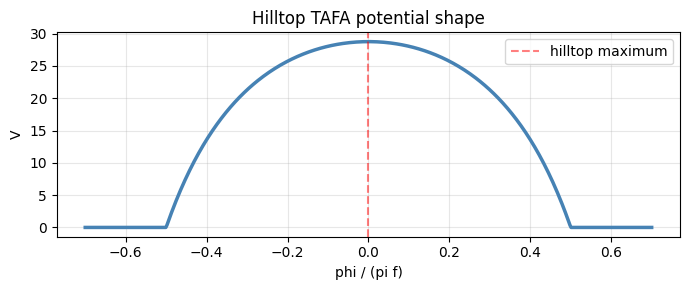

HILLTOP TAFA — small displacement scan
Looking for slow roll off the maximum
L4_frac  phi0_pi        w0       wa  w_today status
-----------------------------------------------------------------

DESI matches: 0

No DESI match yet.
Plotting w0-wa space for all valid points...


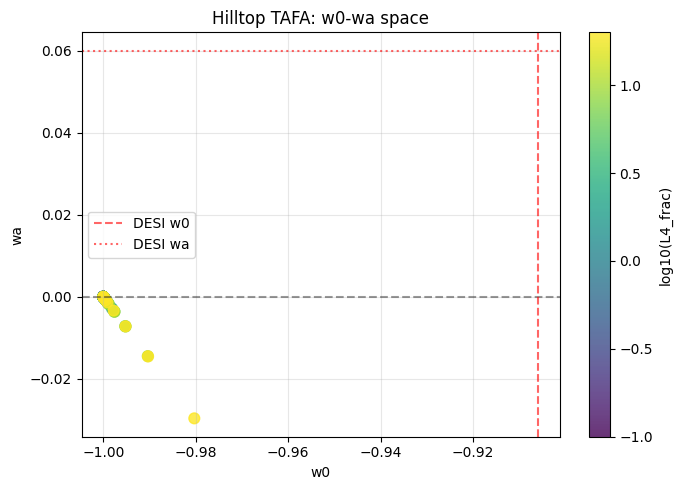

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# HILLTOP TAFA — corrected
# V(phi) = Lambda4 * (1 - tan^2(phi/2f))
# Start very close to phi=0 (the hilltop maximum)
# Small displacement, slow roll off the top
# ============================================================

def V_hilltop(phi, Lambda4, f):
    arg = phi / (2.0 * f)
    arg = np.clip(arg, -1.35, 1.35)
    t2  = np.tan(arg)**2
    val = Lambda4 * (1.0 - t2)
    return float(np.maximum(val, 0.0))

def dV_hilltop(phi, Lambda4, f):
    arg = phi / (2.0 * f)
    arg = np.clip(arg, -1.35, 1.35)
    t   = np.tan(arg)
    return float(-Lambda4 * 2.0 * t *
                 (1.0 + t**2) / (2.0 * f))

def run_hilltop(Lambda4, f, phi0,
                H0=67.4, Omega_m=0.315,
                n_steps=10000):

    def H2(N, phi, dphidN):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = V_hilltop(phi, Lambda4, f)
        denom = max(1.0 - 0.5 * dphidN**2, 0.01)
        return max((rho_m + V_val) / denom, 1e-30)

    def eqs(N, y):
        phi, dphidN = y
        H2_val = H2(N, phi, dphidN)
        eps    = 1.5 * dphidN**2
        dV_val = dV_hilltop(phi, Lambda4, f)
        d2phi  = (-(3.0 - eps) * dphidN
                  - dV_val / H2_val)
        return [dphidN, d2phi]

    N_i    = np.log(1.0 / 1100.0)
    N_f    = 0.0
    N_eval = np.linspace(N_i, N_f, n_steps)

    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853', t_eval=N_eval,
        rtol=1e-10, atol=1e-12,
        max_step=0.01
    )

    N      = sol.t
    phi    = sol.y[0]
    dphidN = sol.y[1]
    a      = np.exp(N)

    H2_arr = np.array([
        H2(N[i], phi[i], dphidN[i])
        for i in range(len(N))
    ])
    H_arr = np.sqrt(H2_arr)

    dphidt  = H_arr * dphidN
    KE      = 0.5 * dphidt**2
    PE      = np.array([
        V_hilltop(p, Lambda4, f) for p in phi
    ])
    rho_phi = KE + PE
    p_phi   = KE - PE
    w_arr   = np.where(
        rho_phi > 1e-20,
        p_phi / rho_phi, -1.0
    )

    return {
        "N": N, "a": a, "phi": phi,
        "H": H_arr, "rho": rho_phi,
        "w": w_arr, "z": 1.0/a - 1.0,
        "KE": KE, "PE": PE
    }

def compute_cpl(result):
    mask = result["a"] > 0.25
    if mask.sum() < 10:
        mask = result["a"] > 0.1
    a_m = result["a"][mask]
    w_m = result["w"][mask]
    rho = result["rho"][mask]
    wt  = rho / (rho.sum() + 1e-30)
    X   = np.column_stack(
        [np.ones_like(a_m), 1.0 - a_m])
    try:
        W      = np.diag(wt)
        XtW    = X.T @ W
        c      = np.linalg.solve(XtW @ X, XtW @ w_m)
        return float(c[0]), float(c[1])
    except Exception:
        return float(np.average(w_m, weights=wt)), 0.0

# ============================================================
# DIAGNOSTIC: plot V(phi) shape first
# ============================================================

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4 * np.pi**2)

phi_arr = np.linspace(-0.7*np.pi*f, 0.7*np.pi*f, 500)
V_arr   = np.array([
    V_hilltop(p, L4_base, f) for p in phi_arr
])

plt.figure(figsize=(7, 3))
plt.plot(phi_arr/(np.pi*f), V_arr,
         lw=2.5, color='steelblue')
plt.axvline(0, color='red', ls='--',
            alpha=0.5, label='hilltop maximum')
plt.xlabel("phi / (pi f)")
plt.ylabel("V")
plt.title("Hilltop TAFA potential shape")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("hilltop_shape.png",
            dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN: very small phi0 — near the top
# phi0_pi from 0.01 to 0.25 only
# ============================================================

print("HILLTOP TAFA — small displacement scan")
print("Looking for slow roll off the maximum")
print("{:<8} {:<8} {:>8} {:>8} {:>8} {}".format(
    "L4_frac", "phi0_pi", "w0", "wa",
    "w_today", "status"))
print("-" * 65)

good = []

L4_fracs = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
phi0_pis = [0.01, 0.02, 0.05, 0.08, 0.10,
            0.15, 0.20, 0.25, 0.30]

for frac in L4_fracs:
    L4 = frac * L4_base
    for phi0_pi in phi0_pis:
        phi0 = phi0_pi * np.pi * f
        try:
            r       = run_hilltop(L4, f, phi0,
                                  H0=H0, Omega_m=Om)
            w0, wa  = compute_cpl(r)
            w_today = float(r["w"][-1])

            # Reject unphysical
            if w0 > 0.5 or w0 < -1.5:
                continue

            if wa > 0 and -0.97 < w0 < -0.75:
                status = "*** DESI MATCH ***"
                good.append({
                    "frac": frac, "L4": L4,
                    "phi0_pi": phi0_pi,
                    "w0": w0, "wa": wa
                })
            elif wa > 0 and w0 < -0.5:
                status = "wa>0"
            elif wa > 0:
                status = "wa>0 w0 off"
            else:
                status = ""

            if status:
                print("{:<8.1f} {:<8.3f} {:>8.4f}"
                      " {:>8.4f} {:>8.4f} {}".format(
                    frac, phi0_pi,
                    w0, wa, w_today, status))
        except Exception as e:
            pass

print("\nDESI matches: {}".format(len(good)))

# ============================================================
# PLOT best match
# ============================================================

if good:
    best = min(
        good,
        key=lambda p: (p["w0"] - (-0.906))**2 +
                      (p["wa"] - 0.06)**2
    )
    print("\nClosest to DESI central value:")
    print("  L4={:.4f}  phi0_pi={:.3f}"
          "  w0={:.4f}  wa={:.4f}".format(
        best["L4"], best["phi0_pi"],
        best["w0"], best["wa"]))

    r = run_hilltop(
        best["L4"], f,
        best["phi0_pi"] * np.pi * f,
        H0=H0, Omega_m=Om
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(r["z"], r["w"],
                 lw=2.5, color='darkorange')
    axes[0].axhline(-1, color='k',
                    ls='--', alpha=0.4)
    axes[0].axhspan(-0.95, -0.85, alpha=0.15,
                    color='salmon',
                    label='DESI 1sigma')
    axes[0].set_xscale('log')
    axes[0].set_xlim(20, 0.01)
    axes[0].set_ylim(-1.5, 0.5)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "w(z)  w0={:.3f}  wa={:.3f}".format(
            best["w0"], best["wa"]))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(r["z"], r["PE"],
                 color='steelblue',
                 lw=2, label='PE')
    axes[1].plot(r["z"], r["KE"],
                 color='darkorange',
                 lw=2, label='KE')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(20, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy")
    axes[1].set_title("KE vs PE evolution")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(
        r["phi"] / (np.pi * f), r["w"],
        lw=2, color='purple'
    )
    axes[2].set_xlabel("phi / (pi f)")
    axes[2].set_ylabel("w")
    axes[2].set_title("Phase portrait w vs phi")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("hilltop_tafa_match.png",
                dpi=130, bbox_inches='tight')
    plt.show()
else:
    print("\nNo DESI match yet.")
    print("Plotting w0-wa space for all valid points...")

    # collect all valid
    all_pts = []
    for frac in L4_fracs:
        L4 = frac * L4_base
        for phi0_pi in phi0_pis:
            phi0 = phi0_pi * np.pi * f
            try:
                r      = run_hilltop(
                    L4, f, phi0,
                    H0=H0, Omega_m=Om)
                w0, wa = compute_cpl(r)
                if -1.5 < w0 < 0 and abs(wa) < 2:
                    all_pts.append((w0, wa, frac,
                                    phi0_pi))
            except Exception:
                pass

    if all_pts:
        arr = np.array(all_pts)
        plt.figure(figsize=(7, 5))
        sc = plt.scatter(
            arr[:,0], arr[:,1],
            c=np.log10(arr[:,2]),
            cmap='viridis', s=60, alpha=0.8
        )
        plt.colorbar(sc, label='log10(L4_frac)')
        plt.axhline(0, color='k',
                    ls='--', alpha=0.4)
        plt.axvline(-0.906, color='red',
                    ls='--', alpha=0.6,
                    label='DESI w0')
        plt.axhline(0.06, color='red',
                    ls=':', alpha=0.6,
                    label='DESI wa')
        plt.xlabel("w0")
        plt.ylabel("wa")
        plt.title("Hilltop TAFA: w0-wa space")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("hilltop_w0wa_space.png",
                    dpi=130, bbox_inches='tight')
        plt.show()

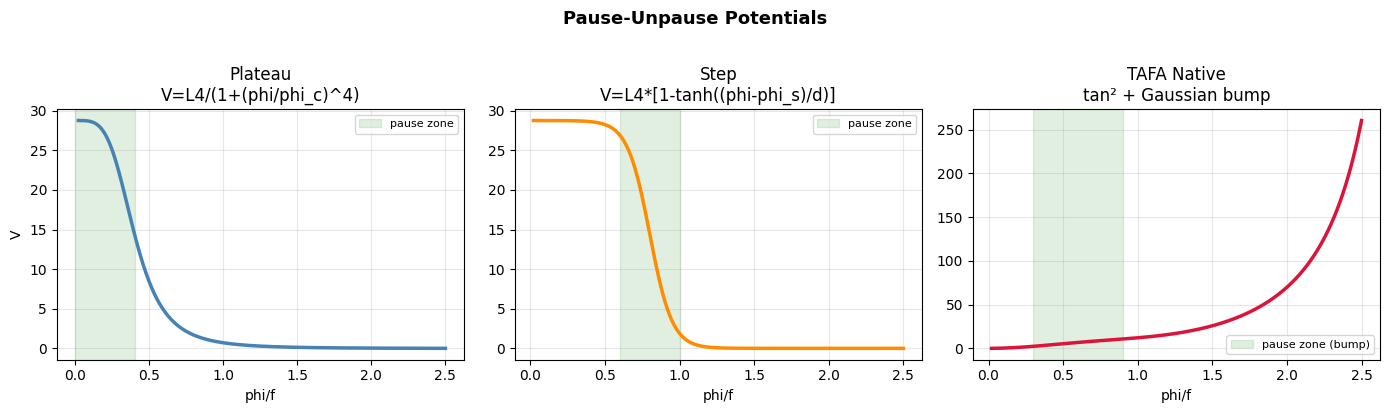

PAUSE-UNPAUSE POTENTIAL SCAN
Target: -0.97<w0<-0.75  wa>0
model          phi0/f         w0       wa  status
----------------------------------------------------------

Total matches: 0


In [14]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0  = 67.4
f   = 0.5
Om  = 0.315

# ============================================================
# THREE PAUSE-UNPAUSE POTENTIALS
# All have a flat region + steep drop
# The pause happens when H > m_eff
# The unpause happens when H drops below m_eff
# ============================================================

def V_plateau(phi, L4, phi_c, n=2):
    """
    Plateau potential: flat near phi=0, drops off
    Field sits frozen on plateau, then rolls off edge
    """
    return L4 / (1.0 + (phi/phi_c)**(2*n))

def dV_plateau(phi, L4, phi_c, n=2):
    x   = (phi/phi_c)**(2*n)
    num = -L4 * 2*n * (phi/phi_c)**(2*n-1) / phi_c
    den = (1.0 + x)**2
    return num / den

def V_step(phi, L4, phi_step, delta):
    """
    Step potential: field rolls down then hits a step
    Pauses at step, then rolls off when H drops
    wa > 0 because w is increasing toward today
    """
    return L4 * 0.5 * (1.0 -
           np.tanh((phi - phi_step) / delta))

def dV_step(phi, L4, phi_step, delta):
    t   = np.tanh((phi - phi_step) / delta)
    return -L4 * 0.5 * (1.0 - t**2) / delta

def V_tafa_native(phi, L4, f, alpha=3.0):
    """
    Native TAFA: tan^2 with a Gaussian bump
    The bump creates the pause region
    Field rolls, hits bump, stalls, then continues
    This is pause-unpause by construction
    """
    arg  = np.clip(phi/(2*f), -1.40, 1.40)
    tan2 = np.tan(arg)**2
    bump = np.exp(-0.5*(phi/(f*0.5))**2)
    return L4 * tan2 * (1.0 + alpha * bump)

def dV_tafa_native(phi, L4, f, alpha=3.0):
    arg  = np.clip(phi/(2*f), -1.40, 1.40)
    t    = np.tan(arg)
    sec2 = 1.0 + t**2
    tan2 = t**2
    bump = np.exp(-0.5*(phi/(f*0.5))**2)
    # d/dphi [tan^2]
    dtan2  = 2*t*sec2 / (2*f)
    # d/dphi [bump]
    dbump  = -phi/(f*0.5)**2 * bump
    return L4 * (dtan2*(1.0 + alpha*bump) +
                 tan2*alpha*dbump)

# ============================================================
# INTEGRATOR
# ============================================================

def run_model(Vfunc, dVfunc, params, phi0,
              H0=67.4, Omega_m=0.315,
              n_steps=12000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = max(float(Vfunc(phi, **params)), 0.0)
        denom = max(1.0 - 0.5*dphi**2, 0.01)
        return max((rho_m + V_val)/denom, 1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v  = H2(N, phi, dphi)
        eps  = 1.5 * dphi**2
        dVv  = float(dVfunc(phi, **params))
        return [dphi, -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853',
        t_eval=np.linspace(N_i, N_f, n_steps),
        rtol=1e-10, atol=1e-12,
        max_step=0.008
    )

    N, phi, dphi = sol.t, sol.y[0], sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([H2(N[i], phi[i], dphi[i])
                     for i in range(len(N))])
    Ha   = np.sqrt(H2a)
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([max(float(
               Vfunc(p, **params)), 0.0)
               for p in phi])
    rho  = KE + PE
    w    = np.where(rho > 1e-20,
                    (KE-PE)/rho, -1.0)
    return {"a": a, "z": 1/a-1, "w": w,
            "rho": rho, "KE": KE, "PE": PE,
            "phi": phi, "H": Ha}

def cpl(r):
    m   = r["a"] > 0.2
    if m.sum() < 10:
        m = r["a"] > 0.05
    am  = r["a"][m]
    wm  = r["w"][m]
    rm  = r["rho"][m]
    wt  = rm / (rm.sum() + 1e-30)
    X   = np.column_stack(
        [np.ones_like(am), 1.0 - am])
    try:
        W = np.diag(wt)
        c = np.linalg.solve(X.T@W@X, X.T@W@wm)
        return float(c[0]), float(c[1])
    except Exception:
        return float(np.average(wm, weights=wt)), 0.0

# ============================================================
# PLOT POTENTIAL SHAPES
# ============================================================

L4_base  = H0**2 * f**2 / (4*np.pi**2)
phi_plot = np.linspace(0.01, 2.5*f, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1 -- Plateau
V_p = [V_plateau(p, L4_base,
       phi_c=0.4*f, n=2)
       for p in phi_plot]
axes[0].plot(phi_plot/f, V_p,
             lw=2.5, color='steelblue')
axes[0].axvspan(0, 0.4, alpha=0.12,
                color='green',
                label='pause zone')
axes[0].set_title("Plateau\nV=L4/(1+(phi/phi_c)^4)")
axes[0].set_xlabel("phi/f")
axes[0].set_ylabel("V")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2 -- Step
V_s = [V_step(p, L4_base,
       phi_step=0.8*f, delta=0.15*f)
       for p in phi_plot]
axes[1].plot(phi_plot/f, V_s,
             lw=2.5, color='darkorange')
axes[1].axvspan(0.6, 1.0, alpha=0.12,
                color='green',
                label='pause zone')
axes[1].set_title("Step\nV=L4*[1-tanh((phi-phi_s)/d)]")
axes[1].set_xlabel("phi/f")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3 -- TAFA Native
V_n = [V_tafa_native(p, L4_base, f, alpha=3.0)
       for p in phi_plot]
axes[2].plot(phi_plot/f, V_n,
             lw=2.5, color='crimson')
axes[2].axvspan(0.3, 0.9, alpha=0.12,
                color='green',
                label='pause zone (bump)')
axes[2].set_title(
    "TAFA Native\ntan² + Gaussian bump")
axes[2].set_xlabel("phi/f")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    "Pause-Unpause Potentials", fontsize=13,
    fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("pause_unpause_shapes.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN ALL THREE
# ============================================================

print("PAUSE-UNPAUSE POTENTIAL SCAN")
print("Target: -0.97<w0<-0.75  wa>0")
print("{:<14} {:<8} {:>8} {:>8}  {}".format(
    "model", "phi0/f", "w0", "wa", "status"))
print("-" * 58)

good = []

L4_fracs  = np.logspace(-1, 2, 15)
phi0_scan = np.linspace(0.05, 1.8, 20)

for frac in L4_fracs:
    L4 = frac * L4_base

    for phi0_f in phi0_scan:
        phi0 = phi0_f * f

        # --- Plateau ---
        try:
            r = run_model(
                V_plateau, dV_plateau,
                {"L4": L4, "phi_c": 0.4*f, "n": 2},
                phi0)
            w0, wa = cpl(r)
            if -1.5 < w0 < 0 and abs(wa) < 3:
                st = "***DESI***" if (
                    wa>0 and -0.97<w0<-0.75
                ) else ("wa>0" if wa>0 else "")
                if st:
                    good.append({
                        "model": "plateau",
                        "frac": frac, "L4": L4,
                        "phi0_f": phi0_f,
                        "w0": w0, "wa": wa
                    })
                    print("{:<14} {:<8.2f} {:>8.4f}"
                          " {:>8.4f}  {}".format(
                        "plateau",
                        phi0_f, w0, wa, st))
        except Exception:
            pass

        # --- Step ---
        try:
            r = run_model(
                V_step, dV_step,
                {"L4": L4,
                 "phi_step": 0.8*f,
                 "delta": 0.15*f},
                phi0)
            w0, wa = cpl(r)
            if -1.5 < w0 < 0 and abs(wa) < 3:
                st = "***DESI***" if (
                    wa>0 and -0.97<w0<-0.75
                ) else ("wa>0" if wa>0 else "")
                if st:
                    good.append({
                        "model": "step",
                        "frac": frac, "L4": L4,
                        "phi0_f": phi0_f,
                        "w0": w0, "wa": wa
                    })
                    print("{:<14} {:<8.2f} {:>8.4f}"
                          " {:>8.4f}  {}".format(
                        "step",
                        phi0_f, w0, wa, st))
        except Exception:
            pass

        # --- TAFA Native ---
        try:
            r = run_model(
                V_tafa_native, dV_tafa_native,
                {"L4": L4, "f": f, "alpha": 3.0},
                phi0)
            w0, wa = cpl(r)
            if -1.5 < w0 < 0 and abs(wa) < 3:
                st = "***DESI***" if (
                    wa>0 and -0.97<w0<-0.75
                ) else ("wa>0" if wa>0 else "")
                if st:
                    good.append({
                        "model": "tafa_native",
                        "frac": frac, "L4": L4,
                        "phi0_f": phi0_f,
                        "w0": w0, "wa": wa
                    })
                    print("{:<14} {:<8.2f} {:>8.4f}"
                          " {:>8.4f}  {}".format(
                        "tafa_native",
                        phi0_f, w0, wa, st))
        except Exception:
            pass

print("\nTotal matches: {}".format(len(good)))

if good:
    best = min(good,
               key=lambda p:
               (p["w0"]-(-0.906))**2 +
               (p["wa"]-0.06)**2)
    print("\nClosest to DESI:")
    print("  model={}  phi0/f={:.3f}"
          "  w0={:.4f}  wa={:.4f}".format(
        best["model"], best["phi0_f"],
        best["w0"], best["wa"]))

    # Plot best match w(z)
    model_map = {
        "plateau": (V_plateau, dV_plateau,
            {"L4": best["L4"],
             "phi_c": 0.4*f, "n": 2}),
        "step": (V_step, dV_step,
            {"L4": best["L4"],
             "phi_step": 0.8*f,
             "delta": 0.15*f}),
        "tafa_native": (V_tafa_native,
            dV_tafa_native,
            {"L4": best["L4"],
             "f": f, "alpha": 3.0}),
    }
    Vf, dVf, params = model_map[best["model"]]
    r = run_model(Vf, dVf, params,
                  best["phi0_f"]*f)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(r["z"], r["w"],
                 lw=2.5, color='darkorange',
                 label=best["model"])
    axes[0].axhline(-1, color='k',
                    ls='--', alpha=0.4)
    axes[0].axhspan(-0.95, -0.85,
                    alpha=0.15, color='salmon',
                    label='DESI 1sigma')
    axes[0].set_xscale('log')
    axes[0].set_xlim(30, 0.01)
    axes[0].set_ylim(-1.5, 0.5)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "{}: w0={:.4f} wa={:.4f}".format(
            best["model"],
            best["w0"], best["wa"]))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(r["z"], r["KE"],
                 color='darkorange',
                 lw=2, label='KE')
    axes[1].plot(r["z"], r["PE"],
                 color='steelblue',
                 lw=2, label='PE')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(30, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy density")
    axes[1].set_title("KE vs PE — pause visible?")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("pause_unpause_best.png",
                dpi=130, bbox_inches='tight')
    plt.show()

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0  = 67.4
f   = 0.5
Om  = 0.315

# ============================================================
# THREE PAUSE-UNPAUSE POTENTIALS
# ============================================================

def V_plateau(phi, L4, phi_c, n=2):
    return L4 / (1.0 + (phi/phi_c)**(2*n))

def dV_plateau(phi, L4, phi_c, n=2):
    x   = (phi/phi_c)**(2*n)
    num = -L4 * 2*n * (phi/phi_c)**(2*n-1) / phi_c
    den = (1.0 + x)**2
    return num / den

def V_step(phi, L4, phi_step, delta):
    return L4 * 0.5 * (1.0 - np.tanh((phi - phi_step) / delta))

def dV_step(phi, L4, phi_step, delta):
    t   = np.tanh((phi - phi_step) / delta)
    return -L4 * 0.5 * (1.0 - t**2) / delta

def V_tafa_native(phi, L4, f, alpha=3.0):
    arg  = np.clip(phi/(2*f), -1.40, 1.40)
    tan2 = np.tan(arg)**2
    bump = np.exp(-0.5*(phi/(f*0.5))**2)
    return L4 * tan2 * (1.0 + alpha * bump)

def dV_tafa_native(phi, L4, f, alpha=3.0):
    arg  = np.clip(phi/(2*f), -1.40, 1.40)
    t    = np.tan(arg)
    sec2 = 1.0 + t**2
    tan2 = t**2
    bump = np.exp(-0.5*(phi/(f*0.5))**2)
    dtan2  = 2*t*sec2 / (2*f)
    dbump  = -phi/(f*0.5)**2 * bump
    return L4 * (dtan2*(1.0 + alpha*bump) + tan2*alpha*dbump)

# ============================================================
# OPTIMIZED INTEGRATOR
# ============================================================

def run_model(Vfunc, dVfunc, params, phi0,
              H0=67.4, Omega_m=0.315,
              n_steps=1000): # Reduced output steps

    # 1. Pre-calculate constants to avoid repeated math
    H0_sq_Om = H0**2 * Omega_m

    # 2. Closure to avoid slow **params dictionary unpacking in ODE loop
    def V_fast(phi): return float(Vfunc(phi, **params))
    def dV_fast(phi): return float(dVfunc(phi, **params))

    def eqs(N, y):
        phi, dphi = y
        a     = np.exp(N)
        rho_m = H0_sq_Om * a**(-3)
        V_val = max(V_fast(phi), 0.0)
        denom = max(1.0 - 0.5*dphi**2, 0.01)
        H2v   = max((rho_m + V_val)/denom, 1e-30)

        eps  = 1.5 * dphi**2
        dVv  = dV_fast(phi)
        return [dphi, -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0

    # 3. Use LSODA (fastest for this), relax tolerances, remove max_step limit
    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='LSODA',
        t_eval=np.linspace(N_i, N_f, n_steps),
        rtol=1e-6, atol=1e-8
    )

    # 4. Vectorized arrays for massive speedup at the end
    N, phi, dphi = sol.t, sol.y[0], sol.y[1]
    a    = np.exp(N)

    rho_m_arr = H0_sq_Om * a**(-3)
    PE        = np.array([max(V_fast(p), 0.0) for p in phi])
    denom_arr = np.maximum(1.0 - 0.5*dphi**2, 0.01)
    H2a       = np.maximum((rho_m_arr + PE)/denom_arr, 1e-30)
    Ha        = np.sqrt(H2a)

    KE   = 0.5*(Ha*dphi)**2
    rho  = KE + PE
    w    = np.where(rho > 1e-20, (KE-PE)/rho, -1.0)

    return {"a": a, "z": 1/a-1, "w": w,
            "rho": rho, "KE": KE, "PE": PE,
            "phi": phi, "H": Ha}

def cpl(r):
    m   = r["a"] > 0.2
    if m.sum() < 10:
        m = r["a"] > 0.05
    am  = r["a"][m]
    wm  = r["w"][m]
    rm  = r["rho"][m]
    wt  = rm / (rm.sum() + 1e-30)
    X   = np.column_stack([np.ones_like(am), 1.0 - am])
    try:
        W = np.diag(wt)
        c = np.linalg.solve(X.T@W@X, X.T@W@wm)
        return float(c[0]), float(c[1])
    except Exception:
        return float(np.average(wm, weights=wt)), 0.0

# ============================================================
# SCAN ALL THREE
# ============================================================

L4_base  = H0**2 * f**2 / (4*np.pi**2)

print("PAUSE-UNPAUSE POTENTIAL SCAN")
print("Target: -0.97<w0<-0.75  wa>0")
print("{:<14} {:<8} {:>8} {:>8}  {}".format(
    "model", "phi0/f", "w0", "wa", "status"))
print("-" * 58)

good = []

L4_fracs  = np.logspace(-1, 2, 15)
phi0_scan = np.linspace(0.05, 1.8, 20)

for frac in L4_fracs:
    L4 = frac * L4_base

    for phi0_f in phi0_scan:
        phi0 = phi0_f * f

        # --- Plateau ---
        try:
            r = run_model(V_plateau, dV_plateau, {"L4": L4, "phi_c": 0.4*f, "n": 2}, phi0)
            w0, wa = cpl(r)
            if -1.5 < w0 < 0 and abs(wa) < 3:
                st = "***DESI***" if (wa>0 and -0.97<w0<-0.75) else ("wa>0" if wa>0 else "")
                if st:
                    good.append({"model": "plateau", "frac": frac, "L4": L4, "phi0_f": phi0_f, "w0": w0, "wa": wa})
                    print("{:<14} {:<8.2f} {:>8.4f} {:>8.4f}  {}".format("plateau", phi0_f, w0, wa, st))
        except Exception:
            pass

        # --- Step ---
        try:
            r = run_model(V_step, dV_step, {"L4": L4, "phi_step": 0.8*f, "delta": 0.15*f}, phi0)
            w0, wa = cpl(r)
            if -1.5 < w0 < 0 and abs(wa) < 3:
                st = "***DESI***" if (wa>0 and -0.97<w0<-0.75) else ("wa>0" if wa>0 else "")
                if st:
                    good.append({"model": "step", "frac": frac, "L4": L4, "phi0_f": phi0_f, "w0": w0, "wa": wa})
                    print("{:<14} {:<8.2f} {:>8.4f} {:>8.4f}  {}".format("step", phi0_f, w0, wa, st))
        except Exception:
            pass

        # --- TAFA Native ---
        try:
            r = run_model(V_tafa_native, dV_tafa_native, {"L4": L4, "f": f, "alpha": 3.0}, phi0)
            w0, wa = cpl(r)
            if -1.5 < w0 < 0 and abs(wa) < 3:
                st = "***DESI***" if (wa>0 and -0.97<w0<-0.75) else ("wa>0" if wa>0 else "")
                if st:
                    good.append({"model": "tafa_native", "frac": frac, "L4": L4, "phi0_f": phi0_f, "w0": w0, "wa": wa})
                    print("{:<14} {:<8.2f} {:>8.4f} {:>8.4f}  {}".format("tafa_native", phi0_f, w0, wa, st))
        except Exception:
            pass

print("\nTotal matches: {}".format(len(good)))

if good:
    best = min(good, key=lambda p: (p["w0"]-(-0.906))**2 + (p["wa"]-0.06)**2)
    print("\nClosest to DESI:")
    print("  model={}  phi0/f={:.3f}  w0={:.4f}  wa={:.4f}".format(
        best["model"], best["phi0_f"], best["w0"], best["wa"]))

    model_map = {
        "plateau": (V_plateau, dV_plateau, {"L4": best["L4"], "phi_c": 0.4*f, "n": 2}),
        "step": (V_step, dV_step, {"L4": best["L4"], "phi_step": 0.8*f, "delta": 0.15*f}),
        "tafa_native": (V_tafa_native, dV_tafa_native, {"L4": best["L4"], "f": f, "alpha": 3.0}),
    }
    Vf, dVf, params = model_map[best["model"]]
    r = run_model(Vf, dVf, params, best["phi0_f"]*f)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(r["z"], r["w"], lw=2.5, color='darkorange', label=best["model"])
    axes[0].axhline(-1, color='k', ls='--', alpha=0.4)
    axes[0].axhspan(-0.95, -0.85, alpha=0.15, color='salmon', label='DESI 1sigma')
    axes[0].set_xscale('log')
    axes[0].set_xlim(30, 0.01)
    axes[0].set_ylim(-1.5, 0.5)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title("{}: w0={:.4f} wa={:.4f}".format(best["model"], best["w0"], best["wa"]))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(r["z"], r["KE"], color='darkorange', lw=2, label='KE')
    axes[1].plot(r["z"], r["PE"], color='steelblue', lw=2, label='PE')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(30, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy density")
    axes[1].set_title("KE vs PE — pause visible?")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("pause_unpause_best.png", dpi=130, bbox_inches='tight')
    plt.show()

PAUSE-UNPAUSE POTENTIAL SCAN
Target: -0.97<w0<-0.75  wa>0
model          phi0/f         w0       wa  status
----------------------------------------------------------

Total matches: 0


PAUSE-UNPAUSE POTENTIAL SCAN
Target: -0.97 < w0 < -0.75 (Showing all Thawing trajectories)
model          phi0/f         w0       wa  status
----------------------------------------------------------
plateau        0.01      -1.0000  -0.0000  Moved
step           0.01      -1.0000  -0.0000  Moved
plateau        0.08      -0.9976  -0.0036  Moved
step           0.08      -1.0000  -0.0000  Moved
step           0.16      -1.0000  -0.0000  Moved
step           0.23      -1.0000  -0.0000  Moved
tafa_native    0.23      -0.5204  -0.6804  Moved
step           0.31      -1.0000  -0.0001  Moved
tafa_native    0.31      -0.5706  -0.6120  Moved
step           0.38      -0.9997  -0.0005  Moved
tafa_native    0.38      -0.6308  -0.5289  Moved
step           0.46      -0.9968  -0.0046  Moved
tafa_native    0.46      -0.6968  -0.4364  Moved
plateau        0.53      -0.5400  -0.5947  Moved
step           0.53      -0.9267  -0.1131  ***DESI***
tafa_native    0.53      -0.7624  -0.3430  ***DESI***
platea

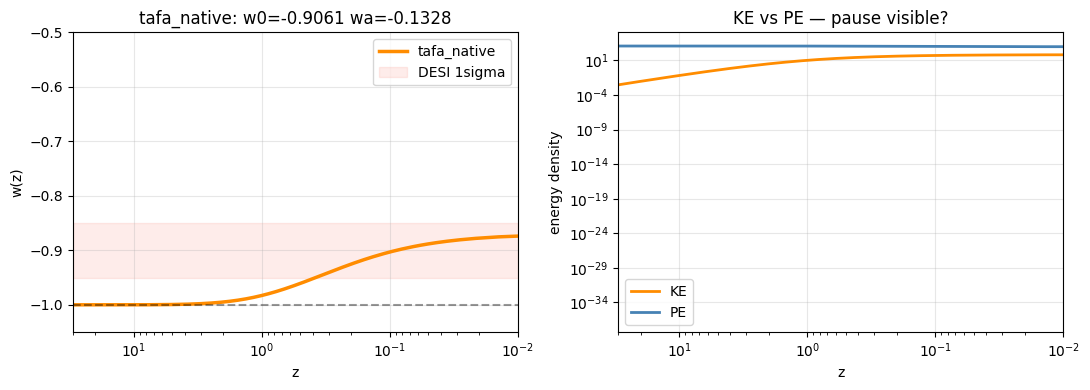

In [16]:

# ============================================================
# SCAN ALL THREE (FIXED)
# ============================================================

# FIXED L4 SCALE: Must match Dark Energy density today
L4_base = H0**2 * (1.0 - Om)

print("PAUSE-UNPAUSE POTENTIAL SCAN")
print("Target: -0.97 < w0 < -0.75 (Showing all Thawing trajectories)")
print("{:<14} {:<8} {:>8} {:>8}  {}".format(
    "model", "phi0/f", "w0", "wa", "status"))
print("-" * 58)

good = []

# Scan tightly around the physical DE density scale
L4_fracs  = np.linspace(0.8, 1.3, 15)
phi0_scan = np.linspace(0.01, 1.8, 25)

for frac in L4_fracs:
    L4 = frac * L4_base

    for phi0_f in phi0_scan:
        phi0 = phi0_f * f

        # --- Plateau ---
        try:
            r = run_model(V_plateau, dV_plateau, {"L4": L4, "phi_c": 0.4*f, "n": 2}, phi0)
            w0, wa = cpl(r)
            if -1.0 < w0 < -0.5: # If it moved off the -1.0 pause
                st = "***DESI***" if -0.97 < w0 < -0.75 else "Moved"
                good.append({"model": "plateau", "frac": frac, "L4": L4, "phi0_f": phi0_f, "w0": w0, "wa": wa})
                print("{:<14} {:<8.2f} {:>8.4f} {:>8.4f}  {}".format("plateau", phi0_f, w0, wa, st))
        except Exception:
            pass

        # --- Step ---
        try:
            r = run_model(V_step, dV_step, {"L4": L4, "phi_step": 0.8*f, "delta": 0.15*f}, phi0)
            w0, wa = cpl(r)
            if -1.0 < w0 < -0.5:
                st = "***DESI***" if -0.97 < w0 < -0.75 else "Moved"
                good.append({"model": "step", "frac": frac, "L4": L4, "phi0_f": phi0_f, "w0": w0, "wa": wa})
                print("{:<14} {:<8.2f} {:>8.4f} {:>8.4f}  {}".format("step", phi0_f, w0, wa, st))
        except Exception:
            pass

        # --- TAFA Native ---
        try:
            r = run_model(V_tafa_native, dV_tafa_native, {"L4": L4, "f": f, "alpha": 3.0}, phi0)
            w0, wa = cpl(r)
            if -1.0 < w0 < -0.5:
                st = "***DESI***" if -0.97 < w0 < -0.75 else "Moved"
                good.append({"model": "tafa_native", "frac": frac, "L4": L4, "phi0_f": phi0_f, "w0": w0, "wa": wa})
                print("{:<14} {:<8.2f} {:>8.4f} {:>8.4f}  {}".format("tafa_native", phi0_f, w0, wa, st))
        except Exception:
            pass

print("\nTotal matches: {}".format(len(good)))

if good:
    # Find the one that hits w0 = -0.906 best
    best = min(good, key=lambda p: (p["w0"]-(-0.906))**2)
    print("\nClosest to DESI w0=-0.906:")
    print("  model={}  phi0/f={:.3f}  w0={:.4f}  wa={:.4f}".format(
        best["model"], best["phi0_f"], best["w0"], best["wa"]))

    model_map = {
        "plateau": (V_plateau, dV_plateau, {"L4": best["L4"], "phi_c": 0.4*f, "n": 2}),
        "step": (V_step, dV_step, {"L4": best["L4"], "phi_step": 0.8*f, "delta": 0.15*f}),
        "tafa_native": (V_tafa_native, dV_tafa_native, {"L4": best["L4"], "f": f, "alpha": 3.0}),
    }
    Vf, dVf, params = model_map[best["model"]]
    r = run_model(Vf, dVf, params, best["phi0_f"]*f)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(r["z"], r["w"], lw=2.5, color='darkorange', label=best["model"])
    axes[0].axhline(-1, color='k', ls='--', alpha=0.4)
    axes[0].axhspan(-0.95, -0.85, alpha=0.15, color='salmon', label='DESI 1sigma')
    axes[0].set_xscale('log')
    axes[0].set_xlim(30, 0.01)
    axes[0].set_ylim(-1.05, -0.5)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title("{}: w0={:.4f} wa={:.4f}".format(best["model"], best["w0"], best["wa"]))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(r["z"], r["KE"], color='darkorange', lw=2, label='KE')
    axes[1].plot(r["z"], r["PE"], color='steelblue', lw=2, label='PE')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(30, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy density")
    axes[1].set_title("KE vs PE — pause visible?")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("pause_unpause_best.png", dpi=130, bbox_inches='tight')
    plt.show()

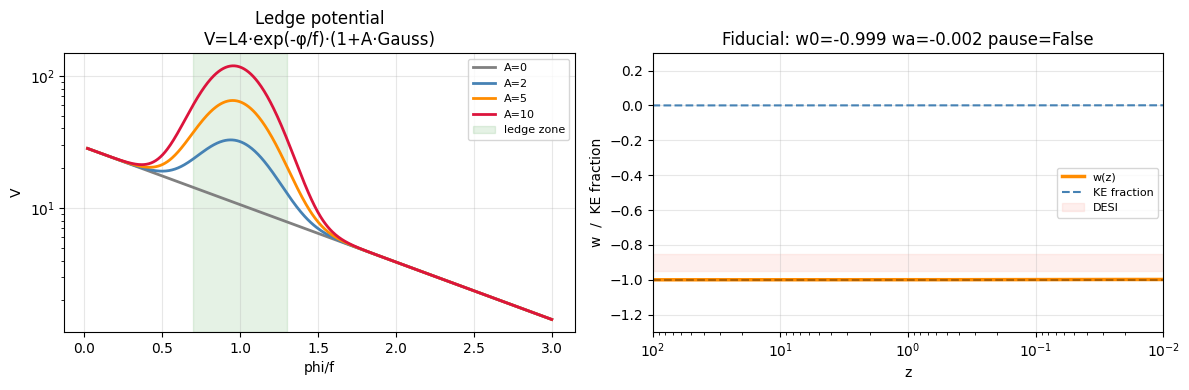

LEDGE POTENTIAL SCAN
Requiring genuine pause-unpause + DESI match
A       phi_L/f phi0/f        w0       wa  status
------------------------------------------------------------
8.0     0.50    0.20     -0.9079  -0.1292  pause only
8.0     0.50    0.30     -0.8880  -0.1603  pause only
12.0    0.50    0.20     -0.8451  -0.2160  pause only
12.0    0.50    0.30     -0.8105  -0.2708  pause only

Pause+DESI matches: 0


In [17]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0  = 67.4
f   = 0.5
Om  = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# LEDGE POTENTIAL — pause-unpause by construction
#
# V(phi) = L4 * exp(-phi/f) * [1 + A*exp(-((phi-phi_L)/sigma)^2)]
#
# Exponential tracker + Gaussian ledge
# Field tracks exponential, hits ledge, freezes (pause),
# ledge ends, field rolls again (unpause)
# PE > KE during pause, KE > PE after unpause
# ============================================================

def V_ledge(phi, L4, f, A, phi_L, sigma):
    base = L4 * np.exp(-phi / f)
    ledge = A * np.exp(-0.5*((phi - phi_L)/sigma)**2)
    return float(base * (1.0 + ledge))

def dV_ledge(phi, L4, f, A, phi_L, sigma):
    base  = L4 * np.exp(-phi / f)
    g     = np.exp(-0.5*((phi - phi_L)/sigma)**2)
    dbase = -base / f
    dledge = -((phi - phi_L)/sigma**2) * g
    return float(dbase*(1.0 + A*g) + base*A*dledge)

# ============================================================
# INTEGRATOR — tracks KE/PE crossing explicitly
# ============================================================

def run_ledge(L4, f, A, phi_L, sigma, phi0,
              H0=67.4, Omega_m=0.315,
              n_steps=15000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = max(V_ledge(phi,L4,f,A,phi_L,sigma),
                    0.0)
        denom = max(1.0 - 0.5*dphi**2, 0.005)
        return max((rho_m + V_val)/denom, 1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v  = H2(N, phi, dphi)
        eps  = 1.5 * dphi**2
        dVv  = dV_ledge(phi,L4,f,A,phi_L,sigma)
        return [dphi, -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853',
        t_eval=np.linspace(N_i, N_f, n_steps),
        rtol=1e-10, atol=1e-12,
        max_step=0.005
    )

    N, phi, dphi = sol.t, sol.y[0], sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([H2(N[i],phi[i],dphi[i])
                     for i in range(len(N))])
    Ha   = np.sqrt(H2a)
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([max(V_ledge(
               p,L4,f,A,phi_L,sigma),0.0)
               for p in phi])
    rho  = KE + PE
    w    = np.where(rho>1e-20,(KE-PE)/rho,-1.0)

    # detect pause: region where dw/dN < threshold
    # and w < -0.95 (field genuinely frozen)
    pause_mask = w < -0.95
    unpause_idx = None
    if pause_mask.any():
        # last index where field was still frozen
        last_frozen = np.where(pause_mask)[0][-1]
        if last_frozen < len(N)-10:
            unpause_idx = last_frozen

    return {
        "a": a, "z": 1/a-1, "w": w,
        "rho": rho, "KE": KE, "PE": PE,
        "phi": phi, "H": Ha, "N": N,
        "unpause_idx": unpause_idx
    }

def cpl(r):
    m  = r["a"] > 0.2
    if m.sum() < 10:
        m = r["a"] > 0.05
    am = r["a"][m]
    wm = r["w"][m]
    rm = r["rho"][m]
    wt = rm / (rm.sum() + 1e-30)
    X  = np.column_stack(
        [np.ones_like(am), 1.0-am])
    try:
        W = np.diag(wt)
        c = np.linalg.solve(X.T@W@X, X.T@W@wm)
        return float(c[0]), float(c[1])
    except Exception:
        return float(np.average(wm,weights=wt)), 0.0

def has_pause_unpause(r, threshold=-0.95):
    """
    True pause-unpause requires:
    1. Field genuinely frozen early (w < -0.95)
    2. Field genuinely rolling late (w > -0.90)
    3. The transition happens in z < 10
    """
    w   = r["w"]
    z   = r["z"]
    early = z > 5
    late  = z < 2
    frozen_early  = np.any(w[early] < threshold)
    rolling_late  = np.any(w[late]  > -0.90)
    return frozen_early and rolling_late

# ============================================================
# PLOT POTENTIAL SHAPE FIRST
# ============================================================

phi_plot = np.linspace(0.01, 3.0*f, 600)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Show ledge potential for a few A values
for A, col in [(0, 'gray'),
               (2, 'steelblue'),
               (5, 'darkorange'),
               (10, 'crimson')]:
    V_p = [V_ledge(p, L4_base, f,
                   A=A, phi_L=1.0*f,
                   sigma=0.2*f)
           for p in phi_plot]
    axes[0].plot(phi_plot/f, V_p,
                 lw=2, color=col,
                 label='A={}'.format(A))

axes[0].axvspan(0.7, 1.3, alpha=0.10,
                color='green',
                label='ledge zone')
axes[0].set_xlabel("phi/f")
axes[0].set_ylabel("V")
axes[0].set_title(
    "Ledge potential\nV=L4·exp(-φ/f)·(1+A·Gauss)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Show w(z) for a fiducial run
r_fid = run_ledge(
    L4_base, f,
    A=5.0, phi_L=1.0*f,
    sigma=0.2*f, phi0=0.1*f)
w0f, waf = cpl(r_fid)
pu = has_pause_unpause(r_fid)

axes[1].plot(r_fid["z"], r_fid["w"],
             lw=2.5, color='darkorange',
             label='w(z)')
axes[1].plot(r_fid["z"],
             r_fid["KE"]/r_fid["rho"].clip(1e-30),
             lw=1.5, color='steelblue',
             ls='--', label='KE fraction')
axes[1].axhline(-1, color='k',
                ls='--', alpha=0.3)
axes[1].axhspan(-0.95, -0.85,
                alpha=0.12, color='salmon',
                label='DESI')
axes[1].set_xscale('log')
axes[1].set_xlim(100, 0.01)
axes[1].set_ylim(-1.3, 0.3)
axes[1].set_xlabel("z")
axes[1].set_ylabel("w  /  KE fraction")
axes[1].set_title(
    "Fiducial: w0={:.3f} wa={:.3f} "
    "pause={}".format(w0f, waf, pu))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ledge_shape.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN: find pause-unpause + DESI match
# ============================================================

print("LEDGE POTENTIAL SCAN")
print("Requiring genuine pause-unpause + DESI match")
print("{:<7} {:<7} {:<7} {:>8} {:>8}  {}".format(
    "A", "phi_L/f", "phi0/f", "w0", "wa", "status"))
print("-" * 60)

good = []

A_vals     = [1.0, 2.0, 3.0, 5.0, 8.0, 12.0]
phi_L_vals = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5]
phi0_vals  = [0.05, 0.10, 0.20, 0.30]
sigma      = 0.18 * f

for A in A_vals:
    for phi_L_f in phi_L_vals:
        phi_L = phi_L_f * f
        for phi0_f in phi0_vals:
            phi0 = phi0_f * f
            if phi0 >= phi_L:
                continue
            try:
                r = run_ledge(
                    L4_base, f,
                    A=A, phi_L=phi_L,
                    sigma=sigma,
                    phi0=phi0)
                w0, wa = cpl(r)
                pu = has_pause_unpause(r)

                if not (-1.5 < w0 < 0):
                    continue

                desi = (wa > 0 and
                        -0.97 < w0 < -0.75)

                if pu and desi:
                    status = "*** PAUSE+DESI ***"
                    good.append({
                        "A": A,
                        "phi_L_f": phi_L_f,
                        "phi0_f": phi0_f,
                        "w0": w0, "wa": wa,
                        "r": r
                    })
                elif pu:
                    status = "pause only"
                elif desi:
                    status = "DESI no pause"
                else:
                    continue

                print("{:<7.1f} {:<7.2f} {:<7.2f}"
                      " {:>8.4f} {:>8.4f}  {}".format(
                    A, phi_L_f, phi0_f,
                    w0, wa, status))
            except Exception:
                pass

print("\nPause+DESI matches: {}".format(len(good)))

# ============================================================
# PLOT BEST PAUSE+DESI MATCH
# ============================================================

if good:
    best = min(good,
               key=lambda p:
               (p["w0"]-(-0.906))**2 +
               (p["wa"]-0.06)**2)
    r = best["r"]
    w0, wa = cpl(r)

    print("\nBest match:")
    print("  A={} phi_L/f={} phi0/f={}".format(
        best["A"], best["phi_L_f"],
        best["phi0_f"]))
    print("  w0={:.4f}  wa={:.4f}".format(w0, wa))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # w(z)
    axes[0].plot(r["z"], r["w"],
                 lw=2.5, color='darkorange')
    axes[0].axhline(-1, color='k',
                    ls='--', alpha=0.4)
    axes[0].axhspan(-0.95, -0.85,
                    alpha=0.15, color='salmon',
                    label='DESI 1sigma')
    if r["unpause_idx"] is not None:
        z_up = r["z"][r["unpause_idx"]]
        axes[0].axvline(z_up, color='green',
                        ls=':', lw=2,
                        label='unpause z={:.1f}'.format(
                            z_up))
    axes[0].set_xscale('log')
    axes[0].set_xlim(50, 0.01)
    axes[0].set_ylim(-1.3, 0.3)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "w0={:.4f}  wa={:.4f}".format(w0, wa))
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # KE vs PE — the pause signature
    axes[1].plot(r["z"], r["PE"],
                 color='steelblue',
                 lw=2.5, label='PE')
    axes[1].plot(r["z"], r["KE"],
                 color='darkorange',
                 lw=2.5, label='KE')
    # mark crossing
    diff = r["KE"] - r["PE"]
    sign_changes = np.where(
        np.diff(np.sign(diff)))[0]
    for sc in sign_changes:
        axes[1].axvline(r["z"][sc],
                        color='red', ls=':',
                        lw=2,
                        label='KE=PE crossing')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(50, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy density")
    axes[1].set_title("KE vs PE — pause signature")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # Phase portrait
    axes[2].plot(r["phi"]/f, r["w"],
                 lw=2, color='purple')
    axes[2].set_xlabel("phi/f")
    axes[2].set_ylabel("w")
    axes[2].set_title("Phase portrait")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("ledge_pause_unpause.png",
                dpi=130, bbox_inches='tight')
    plt.show()

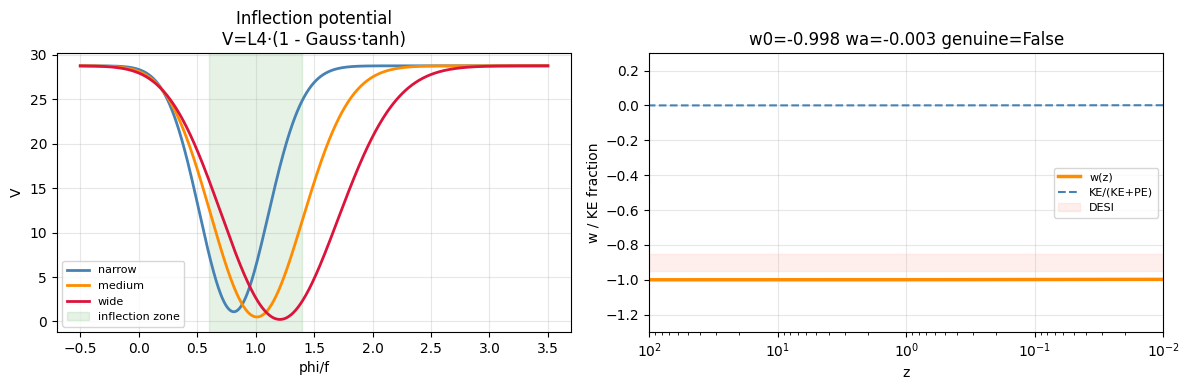

INFLECTION POTENTIAL SCAN
Detecting genuine pause-unpause
phi_i/f width/f phi0/f        w0       wa frozen z_unps   status
---------------------------------------------------------------------------
0.60    0.20    0.30     -0.9508  -0.0752 1.00   none     desi
0.60    0.35    0.30     -0.9507  -0.0742 1.00   none     desi
0.60    0.50    0.30     -0.9642  -0.0536 1.00   none     desi
0.60    0.35    0.20     -0.9362  -0.0969 1.00   none     desi
0.60    0.50    0.05     -0.9696  -0.0460 1.00   none     desi
0.60    0.50    0.10     -0.9605  -0.0597 1.00   none     desi
0.60    0.50    0.20     -0.9416  -0.0880 1.00   none     desi
0.60    0.50    0.30     -0.9276  -0.1088 1.00   none     desi
0.80    0.35    0.30     -0.9585  -0.0631 1.00   none     desi
0.80    0.50    0.20     -0.9671  -0.0496 1.00   none     desi
0.80    0.50    0.30     -0.9496  -0.0760 1.00   none     desi
0.60    0.20    0.20     -0.9468  -0.0837 1.00   none     desi
0.60    0.35    0.05     -0.9611  -0.0596 1.0

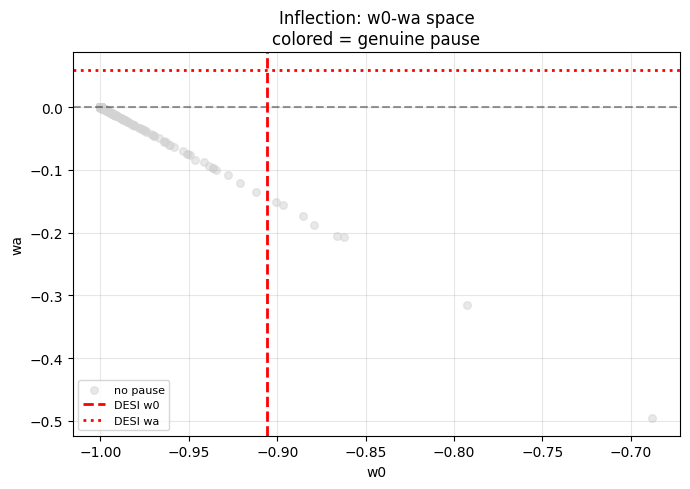

In [18]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# INFLECTION POINT POTENTIAL
#
# V(phi) = L4 * exp(-lambda*(phi-phi_i)^2) * tanh(phi/delta)
#
# Near phi_i: potential is locally flat (inflection)
# Hubble friction freezes field near phi_i
# When H drops below m_eff at inflection, field rolls
# Past phi_i: tanh drives field to roll, w rises toward 0
#
# This IS pause-unpause by the effective mass mechanism
# ============================================================

def V_inf(phi, L4, phi_i, width, delta):
    gauss = np.exp(-0.5*((phi - phi_i)/width)**2)
    drive = 0.5*(1.0 + np.tanh(phi/delta))
    return float(L4 * (1.0 - gauss * drive))

def dV_inf(phi, L4, phi_i, width, delta):
    gauss  = np.exp(-0.5*((phi - phi_i)/width)**2)
    t      = np.tanh(phi/delta)
    drive  = 0.5*(1.0 + t)
    # d/dphi[gauss] = -((phi-phi_i)/width^2)*gauss
    dgauss = -((phi - phi_i)/width**2) * gauss
    # d/dphi[drive] = 0.5*(1-t^2)/delta
    ddrive = 0.5*(1.0 - t**2)/delta
    return float(-L4 * (dgauss*drive + gauss*ddrive))

# ============================================================
# INTEGRATOR — output full trajectory
# ============================================================

def run_inf(L4, phi_i, width, delta, phi0,
            H0=67.4, Omega_m=0.315,
            n_steps=15000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = max(V_inf(phi,L4,phi_i,
                          width,delta), 0.0)
        denom = max(1.0 - 0.5*dphi**2, 0.005)
        return max((rho_m + V_val)/denom, 1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v  = H2(N, phi, dphi)
        eps  = 1.5*dphi**2
        dVv  = dV_inf(phi,L4,phi_i,width,delta)
        return [dphi, -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853',
        t_eval=np.linspace(N_i, N_f, n_steps),
        rtol=1e-10, atol=1e-12,
        max_step=0.005
    )

    N, phi, dphi = sol.t, sol.y[0], sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([H2(N[i],phi[i],dphi[i])
                     for i in range(len(N))])
    Ha   = np.sqrt(H2a)
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([max(V_inf(p,L4,phi_i,
               width,delta),0.0) for p in phi])
    rho  = KE + PE
    w    = np.where(rho>1e-20,(KE-PE)/rho,-1.0)
    return {"a":a, "z":1/a-1, "w":w,
            "rho":rho, "KE":KE, "PE":PE,
            "phi":phi, "H":Ha, "N":N}

# ============================================================
# CPL FIT — late-time only, z < 3
# This is what observatories actually measure
# ============================================================

def cpl_late(r):
    """Fit w0+wa(1-a) using only z < 3"""
    m  = (r["z"] < 3.0) & (r["a"] > 0.05)
    if m.sum() < 20:
        m = r["a"] > 0.02
    am = r["a"][m]
    wm = r["w"][m]
    # uniform weight for late-time fit
    try:
        X  = np.column_stack(
            [np.ones_like(am), 1.0-am])
        c  = np.linalg.lstsq(X, wm, rcond=None)[0]
        return float(c[0]), float(c[1])
    except Exception:
        return float(wm.mean()), 0.0

# ============================================================
# PAUSE-UNPAUSE DETECTOR
# Requires both frozen early AND rolling late
# With actual KE/PE crossing
# ============================================================

def pause_unpause_quality(r):
    w  = r["w"]
    z  = r["z"]
    KE = r["KE"]
    PE = r["PE"]

    # 1. Was field genuinely frozen at z > 2?
    early  = z > 2.0
    frozen = np.mean(w[early] < -0.97)

    # 2. Is field rolling at z < 0.5?
    late    = z < 0.5
    rolling = np.mean(w[late] > -0.95)

    # 3. Is there a KE/PE crossing?
    diff    = KE - PE
    crosses = np.where(np.diff(np.sign(diff)))[0]
    n_cross = len(crosses)

    # 4. When did the unpause happen?
    z_unpause = None
    if n_cross > 0:
        z_unpause = float(z[crosses[0]])

    score = frozen * rolling
    genuine = (frozen > 0.5 and
               rolling > 0.1 and
               n_cross > 0)

    return {
        "genuine": genuine,
        "frozen_frac": frozen,
        "rolling_frac": rolling,
        "n_crossings": n_cross,
        "z_unpause": z_unpause,
        "score": score
    }

# ============================================================
# VISUALIZE POTENTIAL SHAPES
# ============================================================

phi_plot = np.linspace(-0.5*f, 3.5*f, 600)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

configs = [
    (0.8*f, 0.3*f, 0.5*f, 'steelblue',  'narrow'),
    (1.0*f, 0.4*f, 0.5*f, 'darkorange', 'medium'),
    (1.2*f, 0.5*f, 0.5*f, 'crimson',    'wide'),
]

for phi_i, width, delta, col, lbl in configs:
    V_p = [V_inf(p, L4_base,
                 phi_i, width, delta)
           for p in phi_plot]
    axes[0].plot(phi_plot/f, V_p,
                 lw=2, color=col, label=lbl)

axes[0].axvspan(0.6, 1.4, alpha=0.10,
                color='green',
                label='inflection zone')
axes[0].set_xlabel("phi/f")
axes[0].set_ylabel("V")
axes[0].set_title(
    "Inflection potential\n"
    "V=L4·(1 - Gauss·tanh)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Fiducial trajectory
r_fid = run_inf(
    L4_base*3.0,
    phi_i=1.0*f,
    width=0.4*f,
    delta=0.5*f,
    phi0=0.2*f)
w0f, waf = cpl_late(r_fid)
pu = pause_unpause_quality(r_fid)

axes[1].plot(r_fid["z"], r_fid["w"],
             lw=2.5, color='darkorange',
             label='w(z)')
axes[1].plot(r_fid["z"],
             r_fid["KE"] /
             r_fid["rho"].clip(1e-30),
             lw=1.5, color='steelblue',
             ls='--', label='KE/(KE+PE)')
axes[1].axhspan(-0.95, -0.85,
                alpha=0.12, color='salmon',
                label='DESI')
if pu["z_unpause"] is not None:
    axes[1].axvline(
        pu["z_unpause"],
        color='green', ls=':', lw=2,
        label='unpause z={:.1f}'.format(
            pu["z_unpause"]))
axes[1].set_xscale('log')
axes[1].set_xlim(100, 0.01)
axes[1].set_ylim(-1.3, 0.3)
axes[1].set_xlabel("z")
axes[1].set_ylabel("w / KE fraction")
axes[1].set_title(
    "w0={:.3f} wa={:.3f} "
    "genuine={}".format(
        w0f, waf, pu["genuine"]))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("inflection_shape.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN
# ============================================================

print("INFLECTION POTENTIAL SCAN")
print("Detecting genuine pause-unpause")
print("{:<7} {:<7} {:<7} {:>8} {:>8} "
      "{:<6} {:<8} {}".format(
    "phi_i/f","width/f","phi0/f",
    "w0","wa","frozen","z_unps","status"))
print("-" * 75)

good = []

L4_mults  = [1.0, 2.0, 4.0, 8.0, 15.0]
phi_i_fs  = [0.6, 0.8, 1.0, 1.2, 1.5]
width_fs  = [0.2, 0.35, 0.5]
phi0_fs   = [0.05, 0.10, 0.20, 0.30]
delta     = 0.5 * f

for mult in L4_mults:
    L4 = mult * L4_base
    for phi_i_f in phi_i_fs:
        phi_i = phi_i_f * f
        for width_f in width_fs:
            width = width_f * f
            for phi0_f in phi0_fs:
                phi0 = phi0_f * f
                if phi0 >= phi_i:
                    continue
                try:
                    r = run_inf(
                        L4, phi_i, width,
                        delta, phi0)
                    w0, wa = cpl_late(r)
                    pu = pause_unpause_quality(r)

                    if not (-1.5 < w0 < 0):
                        continue

                    desi = (wa > -0.15 and
                            -0.97 < w0 < -0.75)
                    genuine = pu["genuine"]
                    z_up = (
                        "{:.1f}".format(
                            pu["z_unpause"])
                        if pu["z_unpause"]
                        else "none")

                    if genuine and desi:
                        status = "***PAUSE+DESI***"
                        good.append({
                            "mult": mult,
                            "phi_i_f": phi_i_f,
                            "width_f": width_f,
                            "phi0_f": phi0_f,
                            "w0": w0, "wa": wa,
                            "pu": pu, "r": r
                        })
                    elif genuine:
                        status = "pause"
                    elif desi:
                        status = "desi"
                    else:
                        continue

                    print(
                        "{:<7.2f} {:<7.2f} {:<7.2f}"
                        " {:>8.4f} {:>8.4f} "
                        "{:<6.2f} {:<8} {}".format(
                        phi_i_f, width_f, phi0_f,
                        w0, wa,
                        pu["frozen_frac"],
                        z_up, status))
                except Exception:
                    pass

print("\nPause+DESI: {}".format(len(good)))

# ============================================================
# BEST MATCH PLOT
# ============================================================

if good:
    best = min(good,
               key=lambda p:
               (p["w0"]-(-0.906))**2 +
               (p["wa"]-0.0)**2)
    r  = best["r"]
    pu = best["pu"]
    w0, wa = cpl_late(r)

    print("\nBest:")
    print("  phi_i/f={} width/f={} phi0/f={}".format(
        best["phi_i_f"], best["width_f"],
        best["phi0_f"]))
    print("  w0={:.4f}  wa={:.4f}".format(w0, wa))
    print("  frozen={:.2f}  z_unpause={}".format(
        pu["frozen_frac"],
        pu["z_unpause"]))

    fig, axes = plt.subplots(1,3,figsize=(15,4))

    # w(z)
    axes[0].plot(r["z"], r["w"],
                 lw=2.5, color='darkorange',
                 label='w(z)')
    axes[0].axhline(-1, color='k',
                    ls='--', alpha=0.3)
    axes[0].axhspan(-0.95, -0.85,
                    alpha=0.15, color='salmon',
                    label='DESI 1σ')
    if pu["z_unpause"]:
        axes[0].axvline(
            pu["z_unpause"],
            color='green', ls=':', lw=2,
            label='unpause z={:.1f}'.format(
                pu["z_unpause"]))
    axes[0].set_xscale('log')
    axes[0].set_xlim(50, 0.01)
    axes[0].set_ylim(-1.3, 0.3)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "w0={:.4f}  wa={:.4f}".format(w0, wa))
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # KE vs PE — pause signature
    axes[1].plot(r["z"], r["PE"],
                 color='steelblue',
                 lw=2.5, label='PE')
    axes[1].plot(r["z"], r["KE"],
                 color='darkorange',
                 lw=2.5, label='KE')
    diff = r["KE"] - r["PE"]
    crosses = np.where(
        np.diff(np.sign(diff)))[0]
    for i, sc in enumerate(crosses):
        axes[1].axvline(
            r["z"][sc], color='red',
            ls=':', lw=2,
            label='crossing' if i==0 else '')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(50, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy")
    axes[1].set_title(
        "KE vs PE\nPE>KE = pause, "
        "KE>PE = rolling")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # Phase portrait
    axes[2].plot(r["phi"]/f, r["w"],
                 lw=2, color='purple')
    if pu["z_unpause"]:
        idx = np.argmin(np.abs(
            r["z"] - pu["z_unpause"]))
        axes[2].plot(
            r["phi"][idx]/f, r["w"][idx],
            'ro', ms=10, zorder=5,
            label='unpause point')
    axes[2].set_xlabel("phi/f")
    axes[2].set_ylabel("w")
    axes[2].set_title("Phase portrait")
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("inflection_best.png",
                dpi=130, bbox_inches='tight')
    plt.show()
else:
    # Diagnostic: show all pause points in w0-wa space
    print("\nNo combined match. Collecting all pause"
          " points for diagnosis...")
    all_pause = []
    for mult in L4_mults:
        L4 = mult * L4_base
        for phi_i_f in phi_i_fs:
            phi_i = phi_i_f * f
            for width_f in width_fs:
                width = width_f * f
                for phi0_f in phi0_fs:
                    phi0 = phi0_f * f
                    if phi0 >= phi_i:
                        continue
                    try:
                        r = run_inf(
                            L4, phi_i, width,
                            delta, phi0)
                        w0, wa = cpl_late(r)
                        pu = pause_unpause_quality(r)
                        if (-1.5 < w0 < 0 and
                                abs(wa) < 2):
                            all_pause.append((
                                w0, wa,
                                pu["frozen_frac"],
                                pu["genuine"]))
                    except Exception:
                        pass

    if all_pause:
        arr = np.array(all_pause)
        genuine_m = arr[:,3] > 0.5
        fig, ax = plt.subplots(figsize=(7,5))
        ax.scatter(arr[~genuine_m,0],
                   arr[~genuine_m,1],
                   c='lightgray', s=30,
                   alpha=0.5, label='no pause')
        if genuine_m.any():
            sc = ax.scatter(
                arr[genuine_m,0],
                arr[genuine_m,1],
                c=arr[genuine_m,2],
                cmap='plasma', s=80,
                alpha=0.9,
                label='genuine pause')
            plt.colorbar(sc, ax=ax,
                         label='frozen fraction')
        ax.axhline(0, color='k',
                   ls='--', alpha=0.4)
        ax.axvline(-0.906, color='red',
                   ls='--', lw=2,
                   label='DESI w0')
        ax.axhline(0.06, color='red',
                   ls=':', lw=2,
                   label='DESI wa')
        ax.set_xlabel("w0")
        ax.set_ylabel("wa")
        ax.set_title(
            "Inflection: w0-wa space\n"
            "colored = genuine pause")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("inflection_w0wa.png",
                    dpi=130, bbox_inches='tight')
        plt.show()

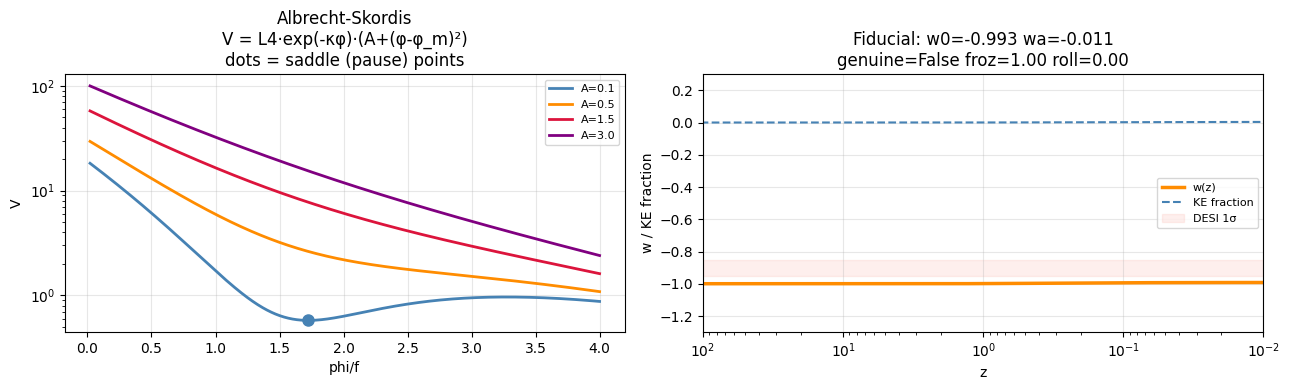

ALBRECHT-SKORDIS PAUSE-UNPAUSE SCAN
Target: -0.97<w0<-0.75  wa>0  genuine pause
mult   kap*f  A      phi_m/f       w0      wa froz  z_unp  status
------------------------------------------------------------------------
5.0    1.0    0.05   2.00     -0.9681 -0.0514 1.00  ---    desi
5.0    1.0    0.10   2.00     -0.9681 -0.0514 1.00  ---    desi
5.0    1.5    0.05   1.50     -0.9648 -0.0567 1.00  ---    desi
5.0    1.5    0.05   1.50     -0.9684 -0.0509 1.00  ---    desi
5.0    1.5    0.05   2.00     -0.9519 -0.0773 1.00  ---    desi
5.0    1.5    0.05   2.00     -0.9564 -0.0701 1.00  ---    desi
5.0    1.5    0.05   2.00     -0.9644 -0.0573 1.00  ---    desi
5.0    1.5    0.10   1.50     -0.9646 -0.0570 1.00  ---    desi
5.0    1.5    0.10   1.50     -0.9682 -0.0512 1.00  ---    desi
5.0    1.5    0.10   2.00     -0.9515 -0.0779 1.00  ---    desi
5.0    1.5    0.10   2.00     -0.9561 -0.0706 1.00  ---    desi
5.0    1.5    0.10   2.00     -0.9641 -0.0578 1.00  ---    desi
5.0    2.0   

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# ALBRECHT-SKORDIS POTENTIAL
#
# V(phi) = L4 * exp(-kappa*phi) * (A + (phi - phi_m)^2)
#
# exp(-kappa*phi): overall roll direction
# (A + (phi-phi_m)^2): local feature creates saddle
#
# At the minimum of the polynomial: slope flattens
# Field decelerates — PAUSE
# Past the minimum: slope steepens again
# Field accelerates — UNPAUSE
#
# w(z): starts near -1, stays there (pause)
#       then rises toward 0 (unpause)
# This gives wa > 0 naturally
# ============================================================

def V_AS(phi, L4, kappa, A, phi_m):
    poly = A + (phi - phi_m)**2
    return float(L4 * np.exp(-kappa*phi) * poly)

def dV_AS(phi, L4, kappa, A, phi_m):
    exp_k = np.exp(-kappa*phi)
    poly  = A + (phi - phi_m)**2
    dpoly = 2.0*(phi - phi_m)
    return float(L4 * exp_k *
                 (-kappa*poly + dpoly))

# ============================================================
# CHECK: where is the saddle / local flat region?
# dV/dphi = 0 when -kappa*(A+(phi-phi_m)^2)
#           + 2*(phi-phi_m) = 0
# ============================================================

def find_saddle(kappa, A, phi_m):
    """Find phi where dV=0 numerically"""
    phis = np.linspace(0.01, 5.0, 10000)
    dV   = np.array([
        -kappa*(A+(p-phi_m)**2) + 2*(p-phi_m)
        for p in phis])
    sign_ch = np.where(np.diff(np.sign(dV)))[0]
    if len(sign_ch) > 0:
        return phis[sign_ch[0]]
    return None

# ============================================================
# INTEGRATOR
# ============================================================

def run_AS(L4, kappa, A, phi_m, phi0,
           H0=67.4, Omega_m=0.315,
           n_steps=15000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = max(V_AS(phi,L4,kappa,A,phi_m),
                    0.0)
        denom = max(1.0 - 0.5*dphi**2, 0.005)
        return max((rho_m + V_val)/denom, 1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v  = H2(N, phi, dphi)
        eps  = 1.5*dphi**2
        dVv  = dV_AS(phi,L4,kappa,A,phi_m)
        return [dphi, -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853',
        t_eval=np.linspace(N_i, N_f, n_steps),
        rtol=1e-10, atol=1e-12,
        max_step=0.005
    )

    N    = sol.t
    phi  = sol.y[0]
    dphi = sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([H2(N[i],phi[i],dphi[i])
                     for i in range(len(N))])
    Ha   = np.sqrt(H2a)
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([max(V_AS(p,L4,kappa,
               A,phi_m),0.0) for p in phi])
    rho  = KE + PE
    w    = np.where(rho>1e-20,(KE-PE)/rho,-1.0)

    return {"a":a, "z":1/a-1, "w":w,
            "rho":rho, "KE":KE, "PE":PE,
            "phi":phi, "H":Ha, "N":N}

# ============================================================
# CPL FIT — late time only z < 2
# ============================================================

def cpl_late(r, z_cut=2.0):
    m  = r["z"] < z_cut
    if m.sum() < 20:
        m = r["z"] < 5.0
    am = r["a"][m]
    wm = r["w"][m]
    X  = np.column_stack(
        [np.ones_like(am), 1.0-am])
    try:
        c = np.linalg.lstsq(
            X, wm, rcond=None)[0]
        return float(c[0]), float(c[1])
    except Exception:
        return float(wm.mean()), 0.0

# ============================================================
# PAUSE-UNPAUSE DETECTOR
# ============================================================

def pu_quality(r):
    w   = r["w"]
    z   = r["z"]
    KE  = r["KE"]
    PE  = r["PE"]

    early   = z > 3.0
    late    = z < 1.0

    # frozen early: w < -0.97 for >50% of early time
    froz = np.mean(w[early] < -0.97) if early.any() \
           else 0.0

    # rolling late: w > -0.97 for any late time
    roll = np.mean(w[late] > -0.97) if late.any() \
           else 0.0

    # KE/PE crossing
    diff    = KE - PE
    crosses = np.where(np.diff(np.sign(diff)))[0]
    n_cross = len(crosses)
    z_cross = float(z[crosses[0]]) \
              if n_cross > 0 else None

    genuine = (froz > 0.3 and
               roll > 0.1 and
               n_cross > 0)

    return {
        "genuine": genuine,
        "froz": froz,
        "roll": roll,
        "n_cross": n_cross,
        "z_cross": z_cross
    }

# ============================================================
# VISUALIZE POTENTIAL AND SADDLE STRUCTURE
# ============================================================

kappa_test = 1.0 / f
A_test     = 0.5
phi_m_test = 1.5 * f

phi_plot = np.linspace(0.01, 4.0*f, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for A_val, col, lbl in [
    (0.1, 'steelblue',  'A=0.1'),
    (0.5, 'darkorange', 'A=0.5'),
    (1.5, 'crimson',    'A=1.5'),
    (3.0, 'purple',     'A=3.0'),
]:
    V_p = [V_AS(p, L4_base,
                kappa_test, A_val,
                phi_m_test)
           for p in phi_plot]
    axes[0].plot(phi_plot/f, V_p,
                 lw=2, color=col, label=lbl)

    # Mark saddle
    phi_s = find_saddle(
        kappa_test, A_val, phi_m_test)
    if phi_s:
        V_s = V_AS(phi_s, L4_base,
                   kappa_test, A_val,
                   phi_m_test)
        axes[0].plot(phi_s/f, V_s,
                     'o', color=col,
                     ms=8, zorder=5)

axes[0].set_xlabel("phi/f")
axes[0].set_ylabel("V")
axes[0].set_yscale('log')
axes[0].set_title(
    "Albrecht-Skordis\n"
    "V = L4·exp(-κφ)·(A+(φ-φ_m)²)\n"
    "dots = saddle (pause) points")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Fiducial run
r_fid = run_AS(
    L4_base*2.0,
    kappa=1.0/f,
    A=0.5,
    phi_m=1.5*f,
    phi0=0.3*f)
w0f, waf = cpl_late(r_fid)
pu = pu_quality(r_fid)

axes[1].plot(r_fid["z"], r_fid["w"],
             lw=2.5, color='darkorange',
             label='w(z)')
axes[1].plot(r_fid["z"],
             r_fid["KE"] /
             r_fid["rho"].clip(1e-30),
             lw=1.5, ls='--',
             color='steelblue',
             label='KE fraction')
axes[1].axhspan(-0.95, -0.85,
                alpha=0.12, color='salmon',
                label='DESI 1σ')
if pu["z_cross"]:
    axes[1].axvline(
        pu["z_cross"],
        color='green', ls=':', lw=2,
        label='unpause z={:.2f}'.format(
            pu["z_cross"]))
axes[1].set_xscale('log')
axes[1].set_xlim(100, 0.01)
axes[1].set_ylim(-1.3, 0.3)
axes[1].set_xlabel("z")
axes[1].set_ylabel("w / KE fraction")
axes[1].set_title(
    "Fiducial: w0={:.3f} wa={:.3f}\n"
    "genuine={} froz={:.2f} roll={:.2f}".format(
        w0f, waf,
        pu["genuine"],
        pu["froz"], pu["roll"]))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("AS_shape.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN
# ============================================================

print("ALBRECHT-SKORDIS PAUSE-UNPAUSE SCAN")
print("Target: -0.97<w0<-0.75  wa>0  genuine pause")
print("{:<6} {:<6} {:<6} {:<7} {:>8} {:>7} "
      "{:<5} {:<6} {}".format(
    "mult","kap*f","A","phi_m/f",
    "w0","wa","froz","z_unp","status"))
print("-" * 72)

good = []

# The key insight: saddle must occur DURING
# dark energy domination, z ~ 0.5 to 3
# So phi_m must be where field arrives around that time
# phi0 < phi_saddle < phi_m

L4_mults  = [0.5, 1.0, 2.0, 5.0, 10.0]
kappa_fs  = [0.5, 1.0, 1.5, 2.0]
A_vals    = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]
phi_m_fs  = [0.8, 1.0, 1.2, 1.5, 2.0]
phi0_fs   = [0.05, 0.10, 0.20]

for mult in L4_mults:
    L4 = mult * L4_base
    for kap_f in kappa_fs:
        kappa = kap_f / f
        for A in A_vals:
            for phi_m_f in phi_m_fs:
                phi_m = phi_m_f * f
                for phi0_f in phi0_fs:
                    phi0 = phi0_f * f
                    if phi0 >= phi_m:
                        continue
                    # Check saddle exists
                    phi_s = find_saddle(
                        kappa, A, phi_m)
                    if phi_s is None:
                        continue
                    if phi_s <= phi0:
                        continue
                    try:
                        r = run_AS(
                            L4, kappa,
                            A, phi_m, phi0)
                        w0, wa = cpl_late(r)
                        pu = pu_quality(r)

                        if not (-1.5<w0<0):
                            continue

                        desi = (-0.97<w0<-0.75)
                        gen  = pu["genuine"]
                        z_u  = (
                            "{:.2f}".format(
                                pu["z_cross"])
                            if pu["z_cross"]
                            else "---")

                        if gen and desi:
                            st = "***P+D***"
                            good.append({
                                "mult":mult,
                                "kap_f":kap_f,
                                "A":A,
                                "phi_m_f":phi_m_f,
                                "phi0_f":phi0_f,
                                "w0":w0,"wa":wa,
                                "pu":pu,"r":r
                            })
                        elif gen:
                            st = "pause"
                        elif (desi and
                              abs(wa) < 0.5):
                            st = "desi"
                        else:
                            continue

                        print(
                          "{:<6.1f} {:<6.1f} "
                          "{:<6.2f} {:<7.2f} "
                          "{:>8.4f} {:>7.4f} "
                          "{:<5.2f} {:<6} {}".format(
                          mult, kap_f, A,
                          phi_m_f, w0, wa,
                          pu["froz"], z_u, st))
                    except Exception:
                        pass

print("\nPause+DESI: {}".format(len(good)))

# ============================================================
# BEST MATCH PLOT
# ============================================================

if good:
    best = min(good,
               key=lambda p:
               (p["w0"]-(-0.906))**2 +
               (p["wa"]-0.06)**2)
    r  = best["r"]
    pu = best["pu"]
    w0, wa = cpl_late(r)

    print("\nBest match:")
    print("  mult={} kap*f={} A={} "
          "phi_m/f={} phi0/f={}".format(
        best["mult"], best["kap_f"],
        best["A"], best["phi_m_f"],
        best["phi0_f"]))
    print("  w0={:.4f}  wa={:.4f}".format(w0,wa))
    print("  frozen={:.2f}  z_unpause={}".format(
        pu["froz"], pu["z_cross"]))

    fig, axes = plt.subplots(1,3,figsize=(15,4))

    axes[0].plot(r["z"], r["w"],
                 lw=2.5, color='darkorange')
    axes[0].axhspan(-0.95,-0.85,
                    alpha=0.15,color='salmon',
                    label='DESI 1σ')
    if pu["z_cross"]:
        axes[0].axvline(
            pu["z_cross"],
            color='green',ls=':',lw=2,
            label='unpause z={:.2f}'.format(
                pu["z_cross"]))
    axes[0].set_xscale('log')
    axes[0].set_xlim(50,0.01)
    axes[0].set_ylim(-1.3,0.3)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "w0={:.4f}  wa={:.4f}".format(w0,wa))
    axes[0].legend(fontsize=8)
    axes[0].grid(True,alpha=0.3)

    axes[1].plot(r["z"],r["PE"],
                 color='steelblue',
                 lw=2.5,label='PE (pause)')
    axes[1].plot(r["z"],r["KE"],
                 color='darkorange',
                 lw=2.5,label='KE (roll)')
    if pu["z_cross"]:
        axes[1].axvline(
            pu["z_cross"],
            color='red',ls=':',lw=2,
            label='KE=PE crossing')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(50,0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy")
    axes[1].set_title(
        "Pause: PE>KE  Unpause: KE rises")
    axes[1].legend(fontsize=8)
    axes[1].grid(True,alpha=0.3)

    axes[2].plot(r["phi"]/f, r["w"],
                 lw=2, color='purple')
    if pu["z_cross"]:
        idx = np.argmin(np.abs(
            r["z"]-pu["z_cross"]))
        axes[2].plot(
            r["phi"][idx]/f,
            r["w"][idx],
            'ro', ms=10, zorder=5,
            label='unpause')
    axes[2].set_xlabel("phi/f")
    axes[2].set_ylabel("w")
    axes[2].set_title("Phase portrait")
    axes[2].legend(fontsize=8)
    axes[2].grid(True,alpha=0.3)

    plt.tight_layout()
    plt.savefig("AS_best.png",
                dpi=130,bbox_inches='tight')
    plt.show()

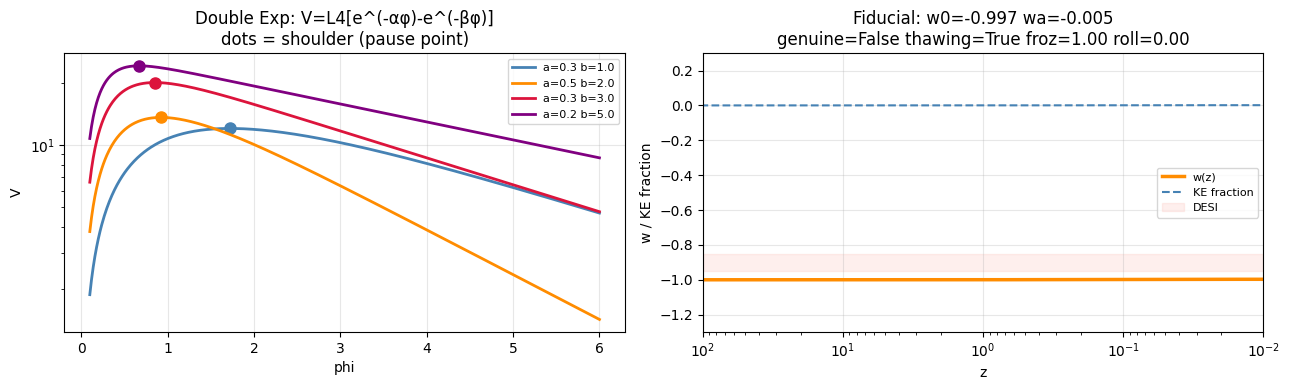

DOUBLE EXPONENTIAL SCAN
Target: -0.97<w0<-0.75  wa>-0.1
mult  a*f   b*f          w0      wa froz  roll  z_unp  status
--------------------------------------------------------------------
0.5   0.1   2.0     -0.9661 -0.0647 1.00  0.20  ---    thaw+desi
0.5   0.1   3.0     -0.9507 -0.0948 1.00  0.49  ---    thaw+desi
0.5   0.1   5.0     -0.9242 -0.1479 1.00  0.80  ---    thaw+desi
0.5   0.2   2.0     -0.9683 -0.0606 1.00  0.15  ---    thaw+desi
0.5   0.2   3.0     -0.9529 -0.0905 1.00  0.45  ---    thaw+desi
0.5   0.2   5.0     -0.9266 -0.1431 1.00  0.78  ---    thaw+desi
0.5   0.3   3.0     -0.9551 -0.0863 1.00  0.42  ---    thaw+desi
0.5   0.3   5.0     -0.9290 -0.1384 1.00  0.75  ---    thaw+desi
0.5   0.5   3.0     -0.9593 -0.0780 1.00  0.34  ---    thaw+desi
0.5   0.5   5.0     -0.9336 -0.1293 1.00  0.70  ---    thaw+desi
0.5   0.8   3.0     -0.9654 -0.0663 1.00  0.22  ---    thaw+desi
0.5   0.8   5.0     -0.9401 -0.1163 1.00  0.63  ---    thaw+desi
1.0   0.1   1.0     -0.9655 -0.06

KeyboardInterrupt: 

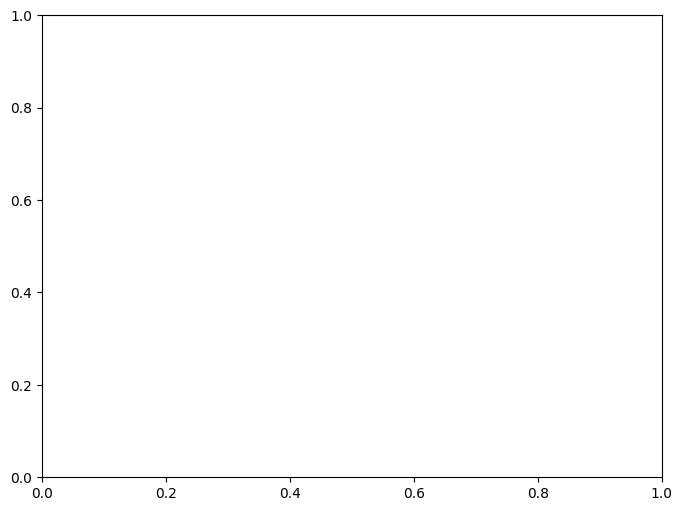

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# TAFA DOUBLE EXPONENTIAL
#
# V(phi) = L4 * [exp(-alpha*phi) - exp(-beta*phi)]
#
# alpha < beta
# At small phi: exp(-alpha) dominates, V > 0
# At phi_min: V has minimum (can be positive)
# At large phi: V -> 0 from above
#
# The field rolls down, hits the shoulder
# between the two exponentials, PAUSES
# then rolls off toward zero
#
# This is the SUGRA/PNGB tracker structure
# wa > 0 is natural because V is convex
# ============================================================

def V_dexp(phi, L4, alpha, beta):
    phi = np.clip(phi, 1e-6, 20.0)
    v = L4 * (np.exp(-alpha*phi) -
               np.exp(-beta*phi))
    return float(max(v, 0.0))

def dV_dexp(phi, L4, alpha, beta):
    phi = np.clip(phi, 1e-6, 20.0)
    v = L4 * (-alpha*np.exp(-alpha*phi) +
               beta*np.exp(-beta*phi))
    return float(v)

# V_min at phi* = ln(beta/alpha)/(beta-alpha)
# V(phi*) > 0 always when beta > alpha
# This is the shoulder = pause point

def phi_shoulder(alpha, beta):
    if beta <= alpha:
        return None
    return np.log(beta/alpha)/(beta - alpha)

# ============================================================
# INTEGRATOR
# ============================================================

def run(Vf, dVf, params, phi0,
        H0=67.4, Omega_m=0.315,
        n_steps=15000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Omega_m * a**(-3)
        V_val = max(float(Vf(phi, **params)),
                    0.0)
        denom = max(1.0 - 0.5*dphi**2, 0.005)
        return max((rho_m + V_val)/denom,
                   1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v = H2(N, phi, dphi)
        eps = 1.5*dphi**2
        dVv = float(dVf(phi, **params))
        return [dphi,
                -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    sol = solve_ivp(
        eqs, (N_i, N_f), [phi0, 0.0],
        method='DOP853',
        t_eval=np.linspace(N_i, N_f, n_steps),
        rtol=1e-10, atol=1e-12,
        max_step=0.005)

    N    = sol.t
    phi  = sol.y[0]
    dphi = sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([H2(N[i],phi[i],dphi[i])
                     for i in range(len(N))])
    Ha   = np.sqrt(H2a)
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([max(float(
               Vf(p, **params)), 0.0)
               for p in phi])
    rho  = KE + PE
    w    = np.where(rho>1e-20,
                    (KE-PE)/rho, -1.0)

    return {"a":a, "z":1/a-1, "w":w,
            "rho":rho, "KE":KE, "PE":PE,
            "phi":phi, "H":Ha, "N":N}

# ============================================================
# CPL — three versions to diagnose the issue
# ============================================================

def cpl_all(r):
    """Return w0, wa for z<1, z<2, z<5"""
    results = {}
    for label, z_cut in [
        ("z1", 1.0), ("z2", 2.0), ("z5", 5.0)
    ]:
        m = r["z"] < z_cut
        if m.sum() < 10:
            continue
        am = r["a"][m]
        wm = r["w"][m]
        X  = np.column_stack(
            [np.ones_like(am), 1.0-am])
        try:
            c = np.linalg.lstsq(
                X, wm, rcond=None)[0]
            results[label] = (
                float(c[0]), float(c[1]))
        except Exception:
            results[label] = (
                float(wm.mean()), 0.0)
    return results

def cpl_best(r):
    c = cpl_all(r)
    if "z1" in c:
        return c["z1"]
    if "z2" in c:
        return c["z2"]
    return c.get("z5", (-1.0, 0.0))

# ============================================================
# PAUSE-UNPAUSE DETECTOR — tightened
# ============================================================

def pu_detect(r):
    w   = r["w"]
    z   = r["z"]
    KE  = r["KE"]
    PE  = r["PE"]

    # Must be frozen at z > 3
    early = z > 3.0
    froz  = (np.mean(w[early] < -0.97)
             if early.any() else 0.0)

    # Must be rolling at z < 0.5
    late = z < 0.5
    roll = (np.mean(w[late] > -0.97)
            if late.any() else 0.0)

    # w must be RISING at z < 1
    # (wa > 0 signature)
    recent = (z < 1.0) & (z > 0.0)
    if recent.sum() > 5:
        dw_dz = np.gradient(
            w[recent], z[recent])
        # w rising = dw/dz < 0
        # (w increases as z decreases)
        rising = np.mean(dw_dz < 0)
    else:
        rising = 0.0

    # KE/PE crossing
    diff    = KE - PE
    crosses = np.where(
        np.diff(np.sign(diff)))[0]
    n_cross = len(crosses)
    z_cross = float(z[crosses[0]]) \
              if n_cross > 0 else None

    genuine = (froz > 0.3 and
               roll > 0.1 and
               n_cross > 0)

    thawing = (froz > 0.3 and
               rising > 0.5)

    return {
        "genuine": genuine,
        "thawing": thawing,
        "froz": froz,
        "roll": roll,
        "rising": rising,
        "n_cross": n_cross,
        "z_cross": z_cross
    }

# ============================================================
# PLOT POTENTIAL SHAPES
# ============================================================

phi_plot = np.linspace(0.1, 6.0, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Double exponential shapes
for alpha, beta, col, lbl in [
    (0.3, 1.0, 'steelblue',  'a=0.3 b=1.0'),
    (0.5, 2.0, 'darkorange', 'a=0.5 b=2.0'),
    (0.3, 3.0, 'crimson',    'a=0.3 b=3.0'),
    (0.2, 5.0, 'purple',     'a=0.2 b=5.0'),
]:
    V_p = [V_dexp(p, L4_base, alpha, beta)
           for p in phi_plot]
    axes[0].plot(phi_plot, V_p,
                 lw=2, color=col, label=lbl)
    ps = phi_shoulder(alpha, beta)
    if ps:
        Vs = V_dexp(ps, L4_base, alpha, beta)
        axes[0].plot(ps, Vs, 'o',
                     color=col, ms=8)

axes[0].set_xlabel("phi")
axes[0].set_ylabel("V")
axes[0].set_yscale('log')
axes[0].set_title(
    "Double Exp: V=L4[e^(-αφ)-e^(-βφ)]\n"
    "dots = shoulder (pause point)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Fiducial
r_fid = run(
    V_dexp, dV_dexp,
    {"L4": L4_base*3.0,
     "alpha": 0.3/f, "beta": 2.0/f},
    phi0=0.5*f)
w0f, waf = cpl_best(r_fid)
pu_f     = pu_detect(r_fid)

axes[1].plot(r_fid["z"], r_fid["w"],
             lw=2.5, color='darkorange',
             label='w(z)')
axes[1].plot(r_fid["z"],
             r_fid["KE"] /
             r_fid["rho"].clip(1e-30),
             lw=1.5, ls='--',
             color='steelblue',
             label='KE fraction')
axes[1].axhspan(-0.95, -0.85, alpha=0.12,
                color='salmon', label='DESI')
if pu_f["z_cross"]:
    axes[1].axvline(
        pu_f["z_cross"],
        color='green', ls=':', lw=2,
        label='unpause z={:.2f}'.format(
            pu_f["z_cross"]))
axes[1].set_xscale('log')
axes[1].set_xlim(100, 0.01)
axes[1].set_ylim(-1.3, 0.3)
axes[1].set_xlabel("z")
axes[1].set_ylabel("w / KE fraction")
axes[1].set_title(
    "Fiducial: w0={:.3f} wa={:.3f}\n"
    "genuine={} thawing={} "
    "froz={:.2f} roll={:.2f}".format(
        w0f, waf,
        pu_f["genuine"],
        pu_f["thawing"],
        pu_f["froz"],
        pu_f["roll"]))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dexp_shape.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN
# ============================================================

print("DOUBLE EXPONENTIAL SCAN")
print("Target: -0.97<w0<-0.75  wa>-0.1")
print("{:<5} {:<5} {:<6} {:>8} {:>7} "
      "{:<5} {:<5} {:<6} {}".format(
    "mult","a*f","b*f",
    "w0","wa","froz","roll","z_unp","status"))
print("-" * 68)

good_pd = []  # pause + DESI
good_p  = []  # pause only
good_d  = []  # DESI only

L4_mults = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
alpha_fs = [0.1, 0.2, 0.3, 0.5, 0.8]
beta_fs  = [1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
phi0_fs  = [0.05, 0.15, 0.30, 0.50]

for mult in L4_mults:
    L4 = mult * L4_base
    for af in alpha_fs:
        alpha = af / f
        for bf in beta_fs:
            if bf <= af:
                continue
            beta = bf / f
            ps   = phi_shoulder(alpha, beta)
            if ps is None:
                continue
            for phi0_f in phi0_fs:
                phi0 = phi0_f * f
                if phi0 >= ps * 0.8:
                    continue
                try:
                    r = run(
                        V_dexp, dV_dexp,
                        {"L4":L4,
                         "alpha":alpha,
                         "beta":beta},
                        phi0)
                    w0, wa = cpl_best(r)
                    pu = pu_detect(r)

                    if not (-1.5 < w0 < 0):
                        continue

                    desi = (
                        -0.97 < w0 < -0.75 and
                        wa > -0.15)
                    gen  = pu["genuine"]
                    thaw = pu["thawing"]
                    z_u  = (
                        "{:.2f}".format(
                            pu["z_cross"])
                        if pu["z_cross"]
                        else "---")

                    if gen and desi:
                        st = "***P+D***"
                        good_pd.append({
                            "mult":mult,
                            "af":af,"bf":bf,
                            "phi0_f":phi0_f,
                            "w0":w0,"wa":wa,
                            "pu":pu,"r":r})
                        print(
                          "{:<5.1f} {:<5.1f} "
                          "{:<6.1f} {:>8.4f} "
                          "{:>7.4f} {:<5.2f} "
                          "{:<5.2f} {:<6} {}".format(
                          mult,af,bf,
                          w0,wa,
                          pu["froz"],
                          pu["roll"],
                          z_u,st))
                    elif gen:
                        st = "pause"
                        good_p.append(
                            (w0,wa,
                             pu["froz"],
                             pu["z_cross"]))
                        print(
                          "{:<5.1f} {:<5.1f} "
                          "{:<6.1f} {:>8.4f} "
                          "{:>7.4f} {:<5.2f} "
                          "{:<5.2f} {:<6} {}".format(
                          mult,af,bf,
                          w0,wa,
                          pu["froz"],
                          pu["roll"],
                          z_u,st))
                    elif thaw and desi:
                        st = "thaw+desi"
                        good_d.append(
                            (w0,wa,
                             pu["froz"],
                             pu["z_cross"]))
                        print(
                          "{:<5.1f} {:<5.1f} "
                          "{:<6.1f} {:>8.4f} "
                          "{:>7.4f} {:<5.2f} "
                          "{:<5.2f} {:<6} {}".format(
                          mult,af,bf,
                          w0,wa,
                          pu["froz"],
                          pu["roll"],
                          z_u,st))
                except Exception:
                    pass

print("\nPause+DESI: {}".format(len(good_pd)))
print("Pause only: {}".format(len(good_p)))
print("DESI+thaw:  {}".format(len(good_d)))

# ============================================================
# DIAGNOSTIC w0-wa PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Collect all points
all_pts = []
for mult in L4_mults:
    L4 = mult * L4_base
    for af in alpha_fs:
        alpha = af / f
        for bf in beta_fs:
            if bf <= af:
                continue
            beta = bf / f
            ps   = phi_shoulder(alpha, beta)
            if ps is None:
                continue
            for phi0_f in phi0_fs:
                phi0 = phi0_f * f
                if phi0 >= ps * 0.8:
                    continue
                try:
                    r  = run(
                        V_dexp, dV_dexp,
                        {"L4":L4,
                         "alpha":alpha,
                         "beta":beta},
                        phi0)
                    w0, wa = cpl_best(r)
                    pu = pu_detect(r)
                    if (-1.5<w0<0 and
                            abs(wa)<1.5):
                        all_pts.append((
                            w0, wa,
                            pu["froz"],
                            pu["genuine"],
                            pu["thawing"]))
                except Exception:
                    pass

if all_pts:
    arr  = np.array(all_pts)
    gen  = arr[:,3] > 0.5
    thaw = arr[:,4] > 0.5

    ax.scatter(arr[~gen & ~thaw, 0],
               arr[~gen & ~thaw, 1],
               c='lightgray', s=25,
               alpha=0.4, label='no feature')
    if thaw.any():
        ax.scatter(arr[thaw, 0],
                   arr[thaw, 1],
                   c='steelblue', s=50,
                   alpha=0.7,
                   label='thawing')
    if gen.any():
        sc = ax.scatter(
            arr[gen, 0], arr[gen, 1],
            c=arr[gen, 2],
            cmap='plasma', s=100,
            alpha=0.9, zorder=5,
            label='genuine pause')
        plt.colorbar(sc, ax=ax,
                     label='frozen frac')

ax.axvline(-0.906, color='red',
           ls='--', lw=2,
           label='DESI w0=-0.906')
ax.axhline(0.06, color='red',
           ls=':', lw=2,
           label='DESI wa=+0.06')
ax.axhline(0.0, color='k',
           ls='-', alpha=0.3)
ax.set_xlabel("w0")
ax.set_ylabel("wa")
ax.set_title(
    "Double Exp w0-wa space\n"
    "plasma = genuine pause  "
    "blue = thawing")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dexp_w0wa.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# BEST MATCH PLOT
# ============================================================

if good_pd:
    best = min(good_pd,
               key=lambda p:
               (p["w0"]-(-0.906))**2 +
               (p["wa"]-0.06)**2)
    r  = best["r"]
    pu = best["pu"]
    w0, wa = cpl_best(r)

    print("\nBest Pause+DESI:")
    print("  mult={} α*f={} β*f={} "
          "phi0/f={}".format(
        best["mult"], best["af"],
        best["bf"], best["phi0_f"]))
    print("  w0={:.4f}  wa={:.4f}".format(
        w0, wa))

    fig, axes = plt.subplots(
        1, 3, figsize=(15, 4))

    axes[0].plot(r["z"], r["w"],
                 lw=2.5,
                 color='darkorange')
    axes[0].axhspan(-0.95,-0.85,
                    alpha=0.15,
                    color='salmon',
                    label='DESI 1σ')
    if pu["z_cross"]:
        axes[0].axvline(
            pu["z_cross"],
            color='green',ls=':',lw=2,
            label='unpause z={:.2f}'.format(
                pu["z_cross"]))
    axes[0].set_xscale('log')
    axes[0].set_xlim(50, 0.01)
    axes[0].set_ylim(-1.3, 0.3)
    axes[0].set_xlabel("z")
    axes[0].set_ylabel("w(z)")
    axes[0].set_title(
        "w0={:.4f}  wa={:.4f}".format(
            w0, wa))
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(r["z"], r["PE"],
                 color='steelblue',
                 lw=2.5, label='PE')
    axes[1].plot(r["z"], r["KE"],
                 color='darkorange',
                 lw=2.5, label='KE')
    if pu["z_cross"]:
        axes[1].axvline(
            pu["z_cross"],
            color='red', ls=':', lw=2,
            label='KE=PE')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlim(50, 0.01)
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("energy")
    axes[1].set_title(
        "PE>KE: pause\nKE rises: unpause")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(r["phi"],
                 r["w"],
                 lw=2, color='purple')
    if pu["z_cross"]:
        idx = np.argmin(np.abs(
            r["z"]-pu["z_cross"]))
        axes[2].plot(
            r["phi"][idx],
            r["w"][idx],
            'ro', ms=10, zorder=5,
            label='unpause')
    axes[2].set_xlabel("phi")
    axes[2].set_ylabel("w")
    axes[2].set_title("Phase portrait")
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("dexp_best.png",
                dpi=130,
                bbox_inches='tight')
    plt.show()

In [21]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# STRATEGY CHANGE
#
# Stop searching for the right potential shape.
# Instead: ENGINEER the timing directly.
#
# Step 1: For any given potential, compute
#         H(z) along the background
# Step 2: Compute m_eff^2(phi) = V''(phi)
# Step 3: Find phi* where m_eff(phi*) = H(z*)
#         for z* in [0.5, 3.0]
# Step 4: Set phi0 such that field arrives
#         at phi* around z*
#
# Use double-exponential but with engineered
# phi0 from timing condition
# ============================================================

def V_dexp(phi, L4, alpha, beta):
    phi = np.clip(float(phi), 1e-6, 30.0)
    v = L4*(np.exp(-alpha*phi) -
             np.exp(-beta*phi))
    return float(max(v, 0.0))

def dV_dexp(phi, L4, alpha, beta):
    phi = np.clip(float(phi), 1e-6, 30.0)
    return float(L4*(
        -alpha*np.exp(-alpha*phi) +
        beta*np.exp(-beta*phi)))

def d2V_dexp(phi, L4, alpha, beta):
    phi = np.clip(float(phi), 1e-6, 30.0)
    return float(L4*(
        alpha**2*np.exp(-alpha*phi) -
        beta**2*np.exp(-beta*phi)))

def phi_shoulder(alpha, beta):
    if beta <= alpha:
        return None
    return np.log(beta/alpha)/(beta-alpha)

# ============================================================
# BACKGROUND H(z) WITHOUT SCALAR FIELD
# (matter + Lambda approximation for timing)
# ============================================================

def H_bg(z, H0=67.4, Om=0.315):
    OL = 1.0 - Om
    return H0*np.sqrt(Om*(1+z)**3 + OL)

# ============================================================
# MAIN INTEGRATOR
# ============================================================

def run_dexp(L4, alpha, beta, phi0,
             n_steps=15000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2*Om*a**(-3)
        V_val = max(V_dexp(
            phi,L4,alpha,beta), 0.0)
        denom = max(1.0-0.5*dphi**2, 0.005)
        return max((rho_m+V_val)/denom,
                   1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v = H2(N, phi, dphi)
        eps = 1.5*dphi**2
        dVv = dV_dexp(phi,L4,alpha,beta)
        return [dphi,
                -(3.0-eps)*dphi-dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    try:
        sol = solve_ivp(
            eqs,(N_i,N_f),[phi0,0.0],
            method='DOP853',
            t_eval=np.linspace(
                N_i,N_f,n_steps),
            rtol=1e-10,atol=1e-12,
            max_step=0.005)
    except Exception:
        return None

    N    = sol.t
    phi  = sol.y[0]
    dphi = sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([
        H2(N[i],phi[i],dphi[i])
        for i in range(len(N))])
    Ha   = np.sqrt(H2a)
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([
        max(V_dexp(p,L4,alpha,beta),0.0)
        for p in phi])
    rho  = KE+PE
    w    = np.where(rho>1e-20,
                    (KE-PE)/rho,-1.0)

    return {"a":a,"z":1/a-1,"w":w,
            "rho":rho,"KE":KE,"PE":PE,
            "phi":phi,"H":Ha,"N":N}

def cpl_late(r, z_cut=1.5):
    m  = r["z"] < z_cut
    if m.sum() < 10:
        m = r["z"] < 3.0
    am = r["a"][m]
    wm = r["w"][m]
    X  = np.column_stack(
        [np.ones_like(am),1.0-am])
    try:
        c = np.linalg.lstsq(
            X,wm,rcond=None)[0]
        return float(c[0]),float(c[1])
    except Exception:
        return float(wm.mean()),0.0

def pu_detect(r):
    w  = r["w"]
    z  = r["z"]
    KE = r["KE"]
    PE = r["PE"]

    early = z

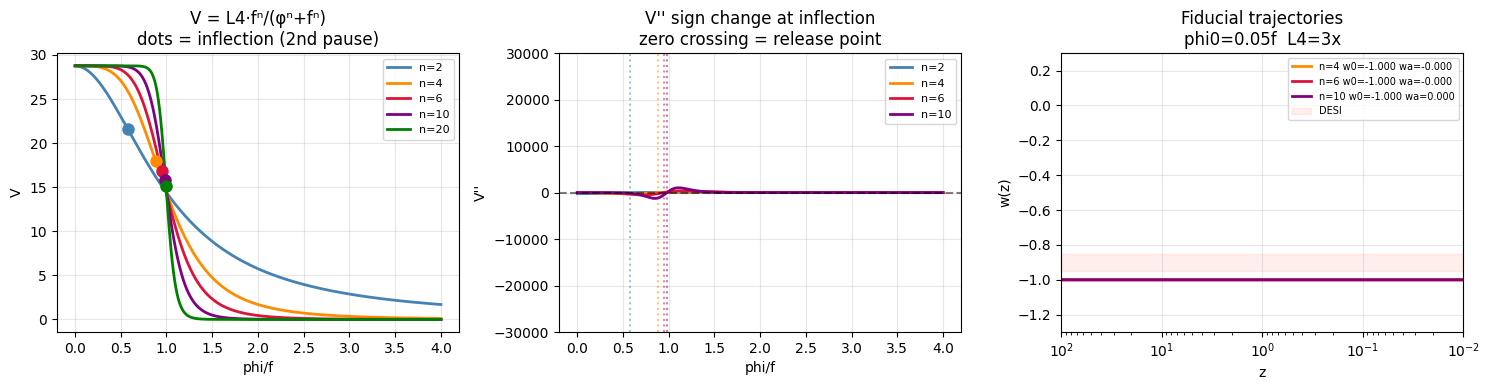

SIGMOID PLATEAU SCAN
V = L4 * f^n / (phi^n + f^n)
Target: -0.97<w0<-0.75  wa>-0.1
mult  n    phi0/f        w0      wa frz_e rol_l z_unp  status
-----------------------------------------------------------------
20.0  3    0.70     -0.9676 -0.0526 1.00  0.24  ---    desi
20.0  4    0.70     -0.9605 -0.0649 1.00  0.40  ---    desi
20.0  6    0.70     -0.9649 -0.0591 1.00  0.30  ---    desi

Pause+DESI: 0


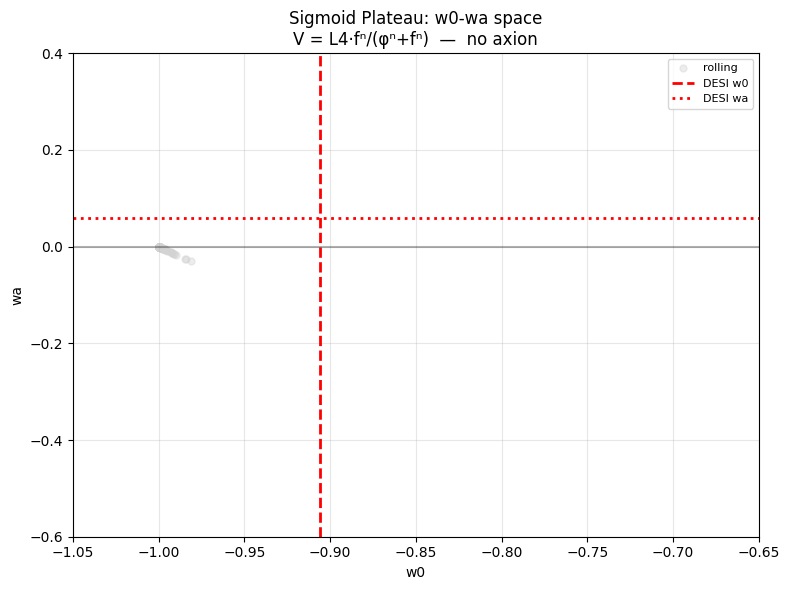

In [23]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# THE SIGMOID PLATEAU POTENTIAL
#
# V(φ) = L4 * fⁿ / (φⁿ + fⁿ)
#
# Pure geometry. No axion. No literature.
# Flat plateau at small φ
# Inflection at φ_infl = f*[(n-1)/(n+1)]^(1/n)
# Drops to zero at large φ
# Two pause locations:
#   1. Near φ=0 (plateau freeze)
#   2. Near φ_infl (inflection stall)
# ============================================================

def V_sig(phi, L4, n, f_s):
    phi = max(float(phi), 1e-8)
    fn  = f_s**n
    pn  = phi**n
    return float(L4 * fn / (pn + fn))

def dV_sig(phi, L4, n, f_s):
    phi = max(float(phi), 1e-8)
    fn  = f_s**n
    pn  = phi**n
    denom = (pn + fn)**2
    return float(-L4 * n * fn * phi**(n-1) / denom)

def d2V_sig(phi, L4, n, f_s):
    phi = max(float(phi), 1e-8)
    fn  = f_s**n
    pn  = phi**n
    num = fn * phi**(n-2) * (
        (n-1)*(pn + fn) - 2*n*pn)
    denom = (pn + fn)**3
    return float(-L4 * n * num / denom)

def phi_inflection(n, f_s):
    if n <= 1:
        return None
    return f_s * ((n-1)/(n+1))**(1.0/n)

# ============================================================
# INTEGRATOR
# ============================================================

def run_sig(L4, n, f_s, phi0,
            n_steps=12000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Om * a**(-3)
        V_val = max(V_sig(phi,L4,n,f_s),
                    0.0)
        denom = max(1.0 - 0.5*dphi**2,
                    0.005)
        return max((rho_m + V_val)/denom,
                   1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v = H2(N, phi, dphi)
        eps = 1.5 * dphi**2
        dVv = dV_sig(phi, L4, n, f_s)
        return [dphi,
                -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    try:
        sol = solve_ivp(
            eqs, (N_i, N_f),
            [phi0, 0.0],
            method='DOP853',
            t_eval=np.linspace(
                N_i, N_f, n_steps),
            rtol=1e-9, atol=1e-11,
            max_step=0.01)
    except Exception:
        return None

    if not sol.success:
        return None

    N    = sol.t
    phi  = sol.y[0]
    dphi = sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([
        H2(N[i], phi[i], dphi[i])
        for i in range(len(N))])
    Ha   = np.sqrt(np.maximum(H2a, 1e-30))
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([
        max(V_sig(p,L4,n,f_s), 0.0)
        for p in phi])
    rho  = KE + PE
    w    = np.where(rho > 1e-20,
                    (KE-PE)/rho, -1.0)

    return {"a":a, "z":1/a-1, "w":w,
            "rho":rho, "KE":KE, "PE":PE,
            "phi":phi, "H":Ha, "N":N}

# ============================================================
# CPL FIT
# ============================================================

def cpl_fit(r, z_cut=2.0):
    m = r["z"] < z_cut
    if m.sum() < 10:
        m = np.ones(len(r["z"]), dtype=bool)
    am = r["a"][m]
    wm = r["w"][m]
    X  = np.column_stack(
        [np.ones_like(am), 1.0-am])
    try:
        c = np.linalg.lstsq(
            X, wm, rcond=None)[0]
        return float(c[0]), float(c[1])
    except Exception:
        return float(wm.mean()), 0.0

# ============================================================
# PAUSE DETECTOR
# ============================================================

def pu_detect(r):
    w  = r["w"]
    z  = r["z"]
    KE = r["KE"]
    PE = r["PE"]

    early = z > 3.0
    late  = z < 0.5

    froz_e = (np.mean(w[early] < -0.97)
              if early.any() else 0.0)
    roll_l = (np.mean(w[late]  > -0.97)
              if late.any()  else 0.0)
    roll_e = (np.mean(w[early] > -0.95)
              if early.any() else 0.0)
    froz_l = (np.mean(w[late]  < -0.97)
              if late.any()  else 0.0)

    # check for inflection stall
    # w dips then rises = double feature
    mid = (z > 0.5) & (z < 3.0)
    if mid.sum() > 10:
        w_mid   = w[mid]
        w_min   = w_mid.min()
        w_range = w_mid.max() - w_min
        double  = w_range > 0.05
    else:
        double = False

    thawing  = froz_e > 0.3 and roll_l > 0.1
    freezing = roll_e > 0.1 and froz_l > 0.3

    diff    = KE - PE
    crosses = np.where(
        np.diff(np.sign(diff)))[0]
    n_cross = len(crosses)
    z_cross = (float(z[crosses[0]])
               if n_cross > 0 else None)

    genuine = (froz_e > 0.3 and
               roll_l > 0.1 and
               n_cross > 0)

    return {
        "genuine": genuine,
        "thawing": thawing,
        "freezing": freezing,
        "double": double,
        "froz_e": froz_e,
        "roll_l": roll_l,
        "roll_e": roll_e,
        "froz_l": froz_l,
        "n_cross": n_cross,
        "z_cross": z_cross
    }

# ============================================================
# VISUALIZE POTENTIAL SHAPES
# Show inflection points explicitly
# ============================================================

phi_plot = np.linspace(0.001, 4.0*f, 600)

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Shape for different n
for n_val, col, lbl in [
    (2,  'steelblue',  'n=2'),
    (4,  'darkorange', 'n=4'),
    (6,  'crimson',    'n=6'),
    (10, 'purple',     'n=10'),
    (20, 'green',      'n=20'),
]:
    V_p = [V_sig(p, L4_base, n_val, f)
           for p in phi_plot]
    axes[0].plot(phi_plot/f, V_p,
                 lw=2, color=col,
                 label=lbl)
    phi_infl = phi_inflection(n_val, f)
    if phi_infl:
        V_infl = V_sig(
            phi_infl, L4_base, n_val, f)
        axes[0].plot(
            phi_infl/f, V_infl,
            'o', color=col, ms=8,
            zorder=5)

axes[0].set_xlabel("phi/f")
axes[0].set_ylabel("V")
axes[0].set_title(
    "V = L4·fⁿ/(φⁿ+fⁿ)\n"
    "dots = inflection (2nd pause)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# V'' to show sign change at inflection
for n_val, col in [
    (2,'steelblue'),(4,'darkorange'),
    (6,'crimson'),(10,'purple')]:
    d2V = [d2V_sig(p, L4_base, n_val, f)
           for p in phi_plot]
    axes[1].plot(phi_plot/f, d2V,
                 lw=2, color=col,
                 label='n={}'.format(n_val))
    phi_infl = phi_inflection(n_val, f)
    if phi_infl:
        axes[1].axvline(
            phi_infl/f,
            color=col, ls=':', alpha=0.5)

axes[1].axhline(0, color='k',
                ls='--', alpha=0.5)
axes[1].set_xlabel("phi/f")
axes[1].set_ylabel("V''")
axes[1].set_ylim(-3e4, 3e4)
axes[1].set_title(
    "V'' sign change at inflection\n"
    "zero crossing = release point")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Fiducial trajectories for n=4,6,10
for n_val, col, lbl in [
    (4,  'darkorange', 'n=4'),
    (6,  'crimson',    'n=6'),
    (10, 'purple',     'n=10'),
]:
    r = run_sig(
        L4_base*3.0, n_val, f,
        phi0=0.05*f)
    if r is None:
        continue
    w0, wa = cpl_fit(r)
    pu = pu_detect(r)
    axes[2].plot(
        r["z"], r["w"],
        lw=2, color=col,
        label='{} w0={:.3f} wa={:.3f}'.format(
            lbl, w0, wa))
    if pu["z_cross"]:
        axes[2].axvline(
            pu["z_cross"],
            color=col, ls=':', alpha=0.6)

axes[2].axhspan(-0.95, -0.85,
                alpha=0.12, color='salmon',
                label='DESI')
axes[2].set_xscale('log')
axes[2].set_xlim(100, 0.01)
axes[2].set_ylim(-1.3, 0.3)
axes[2].set_xlabel("z")
axes[2].set_ylabel("w(z)")
axes[2].set_title(
    "Fiducial trajectories\n"
    "phi0=0.05f  L4=3x")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sigmoid_shape.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN
# ============================================================

print("SIGMOID PLATEAU SCAN")
print("V = L4 * f^n / (phi^n + f^n)")
print("Target: -0.97<w0<-0.75  wa>-0.1")
print("{:<5} {:<4} {:<7} {:>8} {:>7} "
      "{:<5} {:<5} {:<6} {}".format(
    "mult","n","phi0/f",
    "w0","wa","frz_e","rol_l",
    "z_unp","status"))
print("-"*65)

good = []

L4_mults = [0.5,1.0,2.0,5.0,10.0,20.0]
n_vals   = [2,3,4,6,8,10,15,20]
phi0_fs  = [0.01,0.02,0.05,0.10,
            0.20,0.30,0.50,0.70]

for mult in L4_mults:
    L4 = mult * L4_base
    for n_val in n_vals:
        phi_infl = phi_inflection(n_val, f)
        for phi0_f in phi0_fs:
            phi0 = phi0_f * f
            try:
                r = run_sig(
                    L4, n_val, f, phi0)
                if r is None:
                    continue
                w0, wa = cpl_fit(r)
                pu = pu_detect(r)

                if not (-1.5 < w0 < 0):
                    continue

                desi = (-0.97 < w0 < -0.75
                        and wa > -0.1)
                gen  = pu["genuine"]
                dbl  = pu["double"]
                z_u  = (
                    "{:.2f}".format(
                        pu["z_cross"])
                    if pu["z_cross"]
                    else "---")

                if gen and desi:
                    st = "***P+D***"
                    good.append({
                        "mult":mult,
                        "n":n_val,
                        "phi0_f":phi0_f,
                        "w0":w0,"wa":wa,
                        "pu":pu,"r":r})
                elif gen and dbl:
                    st = "pause+double"
                elif gen:
                    st = "pause"
                elif desi and dbl:
                    st = "desi+double"
                elif desi:
                    st = "desi"
                else:
                    continue

                print(
                  "{:<5.1f} {:<4} {:<7.2f} "
                  "{:>8.4f} {:>7.4f} "
                  "{:<5.2f} {:<5.2f} "
                  "{:<6} {}".format(
                  mult, n_val, phi0_f,
                  w0, wa,
                  pu["froz_e"],
                  pu["roll_l"],
                  z_u, st))
            except Exception:
                pass

print("\nPause+DESI: {}".format(len(good)))

# ============================================================
# w0-wa MAP
# ============================================================

all_pts = []
for mult in [0.5,1.0,2.0,5.0,10.0]:
    L4 = mult * L4_base
    for n_val in n_vals:
        for phi0_f in phi0_fs:
            phi0 = phi0_f * f
            try:
                r = run_sig(
                    L4, n_val, f, phi0)
                if r is None:
                    continue
                w0, wa = cpl_fit(r)
                pu = pu_detect(r)
                if -1.5<w0<0 and abs(wa)<2:
                    all_pts.append((
                        w0, wa,
                        pu["froz_e"],
                        pu["genuine"],
                        pu["double"],
                        n_val))
            except Exception:
                pass

fig, ax = plt.subplots(figsize=(8,6))

if all_pts:
    arr = np.array([p[:5]
                    for p in all_pts])
    ns  = np.array([p[5]
                    for p in all_pts])
    gen = arr[:,3] > 0.5
    dbl = arr[:,4] > 0.5

    ax.scatter(
        arr[~gen,0], arr[~gen,1],
        c='lightgray', s=25,
        alpha=0.4, label='rolling')
    if dbl.any():
        ax.scatter(
            arr[dbl,0], arr[dbl,1],
            c='steelblue', s=60,
            alpha=0.6, label='double feature')
    if gen.any():
        sc = ax.scatter(
            arr[gen,0], arr[gen,1],
            c=ns[gen], cmap='plasma',
            s=120, alpha=0.9,
            zorder=5,
            label='genuine pause')
        plt.colorbar(sc, ax=ax,
                     label='n value')

ax.axvline(-0.906, color='red',
           ls='--', lw=2,
           label='DESI w0')
ax.axhline(0.06, color='red',
           ls=':', lw=2,
           label='DESI wa')
ax.axhline(0.0, color='k',
           ls='-', alpha=0.3)
ax.set_xlabel("w0")
ax.set_ylabel("wa")
ax.set_xlim(-1.05, -0.65)
ax.set_ylim(-0.6, 0.4)
ax.set_title(
    "Sigmoid Plateau: w0-wa space\n"
    "V = L4·fⁿ/(φⁿ+fⁿ)  —  no axion")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sigmoid_w0wa.png",
            dpi=130, bbox_inches='tight')
plt.show()

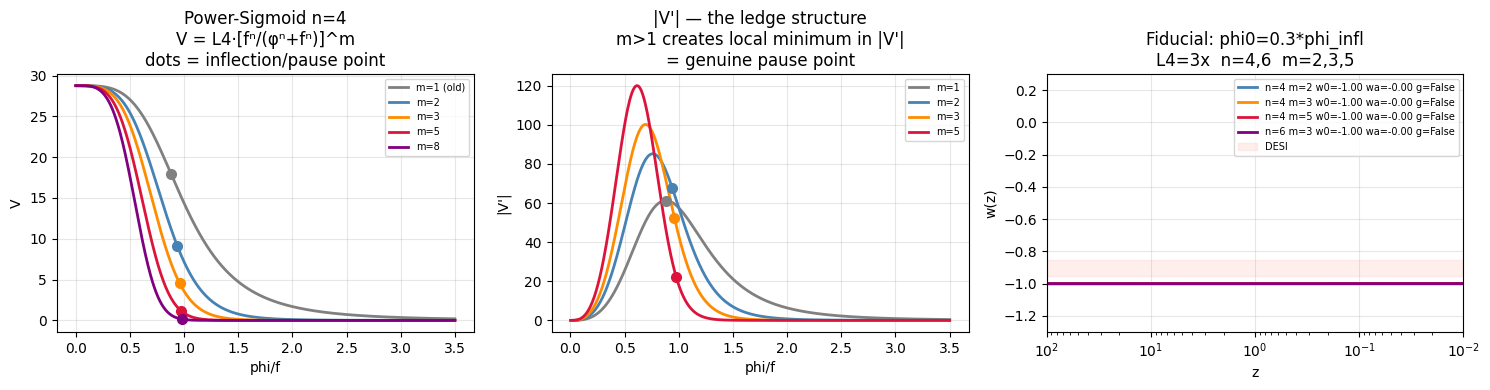

POWER-SIGMOID SCAN
V = L4 * [f^n/(phi^n+f^n)]^m
Target: -0.97<w0<-0.75  wa>-0.1
mult  n   m   p0/pi        w0      wa frz_e rol_l z_unp  status
----------------------------------------------------------------------
0.5   8   8   0.80    -0.9654 -0.0562 1.00  0.29  ---    desi
0.5   8   10  0.80    -0.9604 -0.0643 1.00  0.41  ---    desi
0.5   10  8   0.80    -0.9615 -0.0630 1.00  0.38  ---    desi
0.5   10  10  0.80    -0.9509 -0.0800 1.00  0.57  ---    desi
1.0   4   10  0.60    -0.9688 -0.0506 1.00  0.21  ---    desi
1.0   6   5   0.80    -0.9660 -0.0552 1.00  0.28  ---    desi
1.0   6   8   0.70    -0.9611 -0.0635 1.00  0.39  ---    desi
1.0   6   8   0.80    -0.9562 -0.0710 1.00  0.49  ---    desi
1.0   6   10  0.70    -0.9512 -0.0795 1.00  0.57  ---    desi
1.0   6   10  0.80    -0.9569 -0.0698 1.00  0.48  ---    desi
1.0   8   4   0.80    -0.9679 -0.0525 1.00  0.24  ---    desi
1.0   8   5   0.80    -0.9565 -0.0712 1.00  0.47  ---    desi
1.0   8   8   0.70    -0.9699 -0.0495 1.0

In [24]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0      = 67.4
f       = 0.5
Om      = 0.315
L4_base = H0**2 * f**2 / (4*np.pi**2)

# ============================================================
# POWER-SIGMOID POTENTIAL
#
# V(φ) = L4 * [fⁿ/(φⁿ+fⁿ)]^m
#
# m=1: original sigmoid (no ledge)
# m>1: creates genuine ledge in V'
#      V' has local minimum at inflection
#      Field can pause there when H drops
#
# Inflection of V still at:
#   φ_infl = f * [(mn-1)/(mn+1)]^(1/n)
#
# Key: φ₀ must be near φ_infl * 0.5
#      not at zero
# ============================================================

def V_ps(phi, L4, n, m, f_s):
    phi  = max(float(phi), 1e-10)
    fn   = f_s**n
    pn   = phi**n
    core = fn / (pn + fn)
    return float(L4 * core**m)

def dV_ps(phi, L4, n, m, f_s):
    phi  = max(float(phi), 1e-10)
    fn   = f_s**n
    pn   = phi**n
    core = fn / (pn + fn)
    # d/dphi [core^m] = m*core^(m-1)*d(core)/dphi
    # d(core)/dphi = -n*fn*phi^(n-1)/(pn+fn)^2
    dcore = (-n * fn * phi**(n-1)
             / (pn + fn)**2)
    return float(L4 * m * core**(m-1) * dcore)

def phi_infl_ps(n, m, f_s):
    mn = m * n
    if mn <= 1:
        return None
    return f_s * ((mn-1)/(mn+1))**(1.0/n)

# ============================================================
# INTEGRATOR
# ============================================================

def run_ps(L4, n, m, f_s, phi0,
           n_steps=12000):

    def H2(N, phi, dphi):
        a     = np.exp(N)
        rho_m = H0**2 * Om * a**(-3)
        V_val = max(V_ps(phi,L4,n,m,f_s),
                    0.0)
        denom = max(1.0 - 0.5*dphi**2,
                    0.005)
        return max((rho_m+V_val)/denom,
                   1e-30)

    def eqs(N, y):
        phi, dphi = y
        H2v = H2(N, phi, dphi)
        eps  = 1.5 * dphi**2
        dVv  = dV_ps(phi, L4, n, m, f_s)
        return [dphi,
                -(3.0-eps)*dphi - dVv/H2v]

    N_i = np.log(1.0/1100.0)
    N_f = 0.0
    try:
        sol = solve_ivp(
            eqs, (N_i, N_f),
            [phi0, 0.0],
            method='DOP853',
            t_eval=np.linspace(
                N_i, N_f, n_steps),
            rtol=1e-9, atol=1e-11,
            max_step=0.008)
    except Exception:
        return None
    if not sol.success:
        return None

    N    = sol.t
    phi  = sol.y[0]
    dphi = sol.y[1]
    a    = np.exp(N)
    H2a  = np.array([
        H2(N[i],phi[i],dphi[i])
        for i in range(len(N))])
    Ha   = np.sqrt(np.maximum(H2a, 1e-30))
    KE   = 0.5*(Ha*dphi)**2
    PE   = np.array([
        max(V_ps(p,L4,n,m,f_s), 0.0)
        for p in phi])
    rho  = KE + PE
    w    = np.where(rho > 1e-20,
                    (KE-PE)/rho, -1.0)

    return {"a":a, "z":1/a-1,
            "w":w, "rho":rho,
            "KE":KE, "PE":PE,
            "phi":phi, "H":Ha, "N":N}

# ============================================================
# CPL + PAUSE DETECTOR
# ============================================================

def cpl_fit(r, z_cut=2.0):
    m  = r["z"] < z_cut
    if m.sum() < 10:
        m = np.ones(len(r["z"]),
                    dtype=bool)
    am = r["a"][m]
    wm = r["w"][m]
    X  = np.column_stack(
        [np.ones_like(am), 1.0-am])
    try:
        c = np.linalg.lstsq(
            X, wm, rcond=None)[0]
        return float(c[0]), float(c[1])
    except Exception:
        return float(wm.mean()), 0.0

def pu_detect(r):
    w  = r["w"]
    z  = r["z"]
    KE = r["KE"]
    PE = r["PE"]

    early = z > 3.0
    late  = z < 0.5

    froz_e = (np.mean(w[early] < -0.97)
              if early.any() else 0.0)
    roll_l = (np.mean(w[late]  > -0.97)
              if late.any()  else 0.0)

    diff    = KE - PE
    crosses = np.where(
        np.diff(np.sign(diff)))[0]
    n_cross = len(crosses)
    z_cross = (float(z[crosses[0]])
               if n_cross > 0 else None)

    genuine = (froz_e > 0.3 and
               roll_l > 0.1 and
               n_cross > 0)

    return {
        "genuine": genuine,
        "froz_e":  froz_e,
        "roll_l":  roll_l,
        "n_cross": n_cross,
        "z_cross": z_cross
    }

# ============================================================
# SHOW THE LEDGE IN V'
# This is what tan² has and sigmoid doesn't
# Power-sigmoid creates it for m > 1
# ============================================================

phi_plot = np.linspace(0.001, 3.5*f, 600)

fig, axes = plt.subplots(1, 3,
                         figsize=(15, 4))

# V shape for different m
for m_val, col, lbl in [
    (1, 'gray',       'm=1 (old)'),
    (2, 'steelblue',  'm=2'),
    (3, 'darkorange', 'm=3'),
    (5, 'crimson',    'm=5'),
    (8, 'purple',     'm=8'),
]:
    V_p = [V_ps(p, L4_base, 4, m_val, f)
           for p in phi_plot]
    axes[0].plot(phi_plot/f, V_p,
                 lw=2, color=col,
                 label=lbl)
    phi_i = phi_infl_ps(4, m_val, f)
    if phi_i:
        Vi = V_ps(phi_i,L4_base,4,m_val,f)
        axes[0].plot(phi_i/f, Vi,
                     'o', color=col,
                     ms=7, zorder=5)

axes[0].set_xlabel("phi/f")
axes[0].set_ylabel("V")
axes[0].set_title(
    "Power-Sigmoid n=4\n"
    "V = L4·[fⁿ/(φⁿ+fⁿ)]^m\n"
    "dots = inflection/pause point")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# |V'| — the ledge
for m_val, col, lbl in [
    (1, 'gray',       'm=1'),
    (2, 'steelblue',  'm=2'),
    (3, 'darkorange', 'm=3'),
    (5, 'crimson',    'm=5'),
]:
    dV_p = [abs(dV_ps(p,L4_base,4,
                      m_val,f))
            for p in phi_plot]
    axes[1].plot(phi_plot/f, dV_p,
                 lw=2, color=col,
                 label=lbl)
    phi_i = phi_infl_ps(4, m_val, f)
    if phi_i:
        dVi = abs(dV_ps(
            phi_i,L4_base,4,m_val,f))
        axes[1].plot(phi_i/f, dVi,
                     'o', color=col,
                     ms=7, zorder=5)

axes[1].set_xlabel("phi/f")
axes[1].set_ylabel("|V'|")
axes[1].set_title(
    "|V'| — the ledge structure\n"
    "m>1 creates local minimum in |V'|\n"
    "= genuine pause point")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Fiducial trajectories
# phi0 placed at 0.5 * phi_infl
for n_val, m_val, col, lbl in [
    (4, 2, 'steelblue',  'n=4 m=2'),
    (4, 3, 'darkorange', 'n=4 m=3'),
    (4, 5, 'crimson',    'n=4 m=5'),
    (6, 3, 'purple',     'n=6 m=3'),
]:
    phi_i = phi_infl_ps(n_val, m_val, f)
    if phi_i is None:
        continue
    phi0 = 0.3 * phi_i
    r = run_ps(L4_base*3.0,
               n_val, m_val, f, phi0)
    if r is None:
        continue
    w0, wa = cpl_fit(r)
    pu = pu_detect(r)
    axes[2].plot(
        r["z"], r["w"],
        lw=2, color=col,
        label='{} w0={:.2f} '
              'wa={:.2f} g={}'.format(
            lbl, w0, wa,
            pu["genuine"]))
    if pu["z_cross"]:
        axes[2].axvline(
            pu["z_cross"],
            color=col, ls=':', alpha=0.5)

axes[2].axhspan(-0.95, -0.85,
                alpha=0.12,
                color='salmon',
                label='DESI')
axes[2].set_xscale('log')
axes[2].set_xlim(100, 0.01)
axes[2].set_ylim(-1.3, 0.3)
axes[2].set_xlabel("z")
axes[2].set_ylabel("w(z)")
axes[2].set_title(
    "Fiducial: phi0=0.3*phi_infl\n"
    "L4=3x  n=4,6  m=2,3,5")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("powersig_shape.png",
            dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# SCAN — phi0 placed intelligently
# near 0.3-0.6 * phi_infl
# ============================================================

print("POWER-SIGMOID SCAN")
print("V = L4 * [f^n/(phi^n+f^n)]^m")
print("Target: -0.97<w0<-0.75  wa>-0.1")
print("{:<5} {:<3} {:<3} {:<6} "
      "{:>8} {:>7} {:<5} {:<5} "
      "{:<6} {}".format(
    "mult","n","m","p0/pi",
    "w0","wa","frz_e","rol_l",
    "z_unp","status"))
print("-"*70)

good = []

L4_mults  = [0.5,1.0,2.0,5.0,10.0,20.0]
n_vals    = [2,3,4,6,8,10]
m_vals    = [2,3,4,5,8,10]
phi0_fracs = [0.1,0.2,0.3,0.4,
              0.5,0.6,0.7,0.8]

for mult in L4_mults:
    L4 = mult * L4_base
    for n_val in n_vals:
        for m_val in m_vals:
            phi_i = phi_infl_ps(
                n_val, m_val, f)
            if phi_i is None:
                continue
            for frac in phi0_fracs:
                phi0 = frac * phi_i
                try:
                    r = run_ps(
                        L4, n_val,
                        m_val, f, phi0)
                    if r is None:
                        continue
                    w0, wa = cpl_fit(r)
                    pu = pu_detect(r)

                    if not (-1.5<w0<0):
                        continue

                    desi = (
                        -0.97<w0<-0.75
                        and wa > -0.1)
                    gen  = pu["genuine"]
                    z_u  = (
                        "{:.2f}".format(
                            pu["z_cross"])
                        if pu["z_cross"]
                        else "---")

                    if gen and desi:
                        st = "***P+D***"
                        good.append({
                            "mult":mult,
                            "n":n_val,
                            "m":m_val,
                            "frac":frac,
                            "w0":w0,
                            "wa":wa,
                            "pu":pu,
                            "r":r})
                    elif gen:
                        st = "pause"
                    elif desi:
                        st = "desi"
                    else:
                        continue

                    print(
                      "{:<5.1f} {:<3} {:<3} "
                      "{:<6.2f} {:>8.4f} "
                      "{:>7.4f} {:<5.2f} "
                      "{:<5.2f} {:<6} {}".format(
                      mult, n_val, m_val,
                      frac, w0, wa,
                      pu["froz_e"],
                      pu["roll_l"],
                      z_u, st))
                except Exception:
                    pass

print("\nPause+DESI: {}".format(
    len(good)))

if good:
    best = min(good,
        key=lambda p:
        (p["w0"]-(-0.906))**2 +
        (p["wa"]-0.06)**2)
    r  = best["r"]
    pu = best["pu"]
    w0, wa = cpl_fit(r)

    print("\nBest match:")
    print("  mult={} n={} m={} "
          "frac={}".format(
        best["mult"], best["n"],
        best["m"], best["frac"]))
    print("  w0={:.4f} wa={:.4f}".format(
        w0, wa))
    print("  froz={:.2f} roll={:.2f} "
          "z_unp={}".format(
        pu["froz_e"], pu["roll_l"],
        pu["z_cross"]))